In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv")

In [2]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.0,471.375260,0,0.000783,1.0,1.219421,1.039677,3,1414.125780,1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.4,754.811217,0,0.000154,1.0,1.172288,10.813781,6,4528.867303,1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.0,520.297395,0,0.000783,1.0,0.958735,6.406862,5,2601.486975,1
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,1.0,986.821602,0,0.000692,1.0,1.109330,0.795094,1,986.821602,1
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,1.0,1754.958804,0,0.000495,1.0,1.203289,4.415985,4,7019.835216,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   sale_id                 1040200 non-null  str    
 1   sale_date               1040200 non-null  str    
 2   store_id                1040200 non-null  str    
 3   product_id              1040200 non-null  str    
 4   quantity                1040200 non-null  int64  
 5   product_name            1040200 non-null  str    
 6   launch_date             1040200 non-null  str    
 7   price                   1040200 non-null  int64  
 8   store_name              1040200 non-null  str    
 9   city                    1040200 non-null  str    
 10  category_id             1040200 non-null  str    
 11  category_name           1040200 non-null  str    
 12  sales_amount            1040200 non-null  int64  
 13  invalid_launch_flag     1040200 non-null  bool   
 14  product_age_d

In [4]:
print(df.columns)

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm_mapped', 'year', 'gdp_type',
       'gdp_per_capita', 'season_factor', 'economic_factor', 'promo_flag',
       'promo_factor', 'price_realistic', 'days_from_start', 'product_trend',
       'trend_factor', 'store_factor', 'mu_demand', 'quantity_realistic',
       'sales_amount_realistic', 'month'],
      dtype='str')


In [5]:
df.shape

(1040200, 35)

In [6]:
# تحويل sales_date إلى datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])

# تأكيد
print(df['sale_date'].head())
print(df['sale_date'].dtype)

0   2020-01-01
1   2020-01-01
2   2020-01-01
3   2020-01-01
4   2020-01-01
Name: sale_date, dtype: datetime64[us]
datetime64[us]


In [7]:
# استخراج السنة والشهر
df['year'] = df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month

In [8]:
# تجميع شهري لكل Store
monthly_df = (
    df.groupby(['store_name', 'year', 'month'], as_index=False)
      .agg({'sales_amount_realistic': 'sum'})
)

In [9]:
# ترتيب زمني
monthly_df = monthly_df.sort_values(
    by=['store_name', 'year', 'month']
).reset_index(drop=True)

monthly_df.head()

,store_name,year,month,sales_amount_realistic
0,Apple Ala Moana,2020,1,1.698421e+06
1,Apple Ala Moana,2020,2,2.467761e+06
2,Apple Ala Moana,2020,3,2.519131e+06
3,Apple Ala Moana,2020,4,2.559084e+06
4,Apple Ala Moana,2020,5,2.303685e+06


In [10]:
monthly_df.groupby('store_name').size().describe()

count    69.0
mean     59.0
std       0.0
min      59.0
25%      59.0
50%      59.0
75%      59.0
max      59.0
dtype: float64

In [11]:
monthly_df['date'] = pd.to_datetime(
    monthly_df['year'].astype(str) + '-' +
    monthly_df['month'].astype(str) + '-01'
)

monthly_df = monthly_df.sort_values(['store_name', 'date']).reset_index(drop=True)

In [12]:
monthly_df['store_id'] = monthly_df['store_name'].astype('category').cat.codes

In [13]:
import numpy as np

monthly_df['month_sin'] = np.sin(2 * np.pi * monthly_df['month'] / 12)
monthly_df['month_cos'] = np.cos(2 * np.pi * monthly_df['month'] / 12)

In [14]:
for lag in [1, 3, 6, 12]:
    monthly_df[f'lag_{lag}'] = (
        monthly_df
        .groupby('store_id')['sales_amount_realistic']
        .shift(lag)
    )

In [15]:
monthly_df['rolling_mean_3'] = (
    monthly_df
    .groupby('store_id')['sales_amount_realistic']
    .shift(1)
    .rolling(3)
    .mean()
)

monthly_df['rolling_mean_6'] = (
    monthly_df
    .groupby('store_id')['sales_amount_realistic']
    .shift(1)
    .rolling(6)
    .mean()
)

In [16]:
monthly_df = monthly_df.dropna().reset_index(drop=True)

In [17]:
print(df.columns)

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm_mapped', 'year', 'gdp_type',
       'gdp_per_capita', 'season_factor', 'economic_factor', 'promo_flag',
       'promo_factor', 'price_realistic', 'days_from_start', 'product_trend',
       'trend_factor', 'store_factor', 'mu_demand', 'quantity_realistic',
       'sales_amount_realistic', 'month'],
      dtype='str')


In [18]:
monthly_df.columns

Index(['store_name', 'year', 'month', 'sales_amount_realistic', 'date',
       'store_id', 'month_sin', 'month_cos', 'lag_1', 'lag_3', 'lag_6',
       'lag_12', 'rolling_mean_3', 'rolling_mean_6'],
      dtype='str')

In [19]:
monthly_df[['sales_amount_realistic',
            'lag_1',
            'lag_3',
            'lag_12',
            'rolling_mean_3']].head(10)

,sales_amount_realistic,lag_1,lag_3,lag_12,rolling_mean_3
0,2.077733e+06,3.330574e+06,2.459427e+06,1.698421e+06,2.884366e+06
1,1.879475e+06,2.077733e+06,2.863096e+06,2.467761e+06,2.757135e+06
2,2.999936e+06,1.879475e+06,3.330574e+06,2.519131e+06,2.429261e+06
3,2.607050e+06,2.999936e+06,2.077733e+06,2.559084e+06,2.319048e+06
4,2.468280e+06,2.607050e+06,1.879475e+06,2.303685e+06,2.495487e+06
5,2.583542e+06,2.468280e+06,2.999936e+06,2.724756e+06,2.691756e+06
6,2.721883e+06,2.583542e+06,2.607050e+06,2.753674e+06,2.552958e+06
7,2.776345e+06,2.721883e+06,2.468280e+06,2.872658e+06,2.591235e+06
8,2.857776e+06,2.776345e+06,2.583542e+06,2.708092e+06,2.693924e+06
9,2.379578e+06,2.857776e+06,2.721883e+06,2.459427e+06,2.785335e+06


In [20]:
feature_cols = [
    'store_id',
    'month_sin',
    'month_cos',
    'lag_1',
    'lag_3',
    'lag_6',
    'lag_12',
    'rolling_mean_3',
    'rolling_mean_6'
]

In [21]:
target_col = 'sales_amount_realistic'

In [22]:
X = monthly_df[feature_cols]
y = monthly_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (3243, 9)
y shape: (3243,)


,store_id,month_sin,month_cos,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6
0,0,0.500000,8.660254e-01,3.330574e+06,2.459427e+06,2.753674e+06,1.698421e+06,2.884366e+06,2.831254e+06
1,0,0.866025,5.000000e-01,2.077733e+06,2.863096e+06,2.872658e+06,2.467761e+06,2.757135e+06,2.718597e+06
2,0,1.000000,6.123234e-17,1.879475e+06,3.330574e+06,2.708092e+06,2.519131e+06,2.429261e+06,2.553066e+06
3,0,0.866025,-5.000000e-01,2.999936e+06,2.077733e+06,2.459427e+06,2.559084e+06,2.319048e+06,2.601707e+06
4,0,0.500000,-8.660254e-01,2.607050e+06,1.879475e+06,2.863096e+06,2.303685e+06,2.495487e+06,2.626311e+06


In [23]:
from sklearn.model_selection import train_test_split

# نحافظ على الترتيب الزمني
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [25]:
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[ 5.00823074e-17 -4.69521632e-18 -2.33782646e-17 -1.06424903e-16
 -1.25205768e-16 -1.62767499e-16 -5.94727400e-17 -3.44315863e-17
  3.75617305e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [26]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

In [27]:
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []

    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])

    return np.array(X_seq), np.array(y_seq)

In [28]:
window_size = 12

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_scaled.flatten(), window_size
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled, y_val_scaled.flatten(), window_size
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_scaled.flatten(), window_size
)

In [29]:
print(X_train_seq.shape)
print(y_train_seq.shape)

(2258, 12, 9)
(2258,)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [31]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

d:\anaconda\envs\Apple\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.4220 - mae: 0.4602 - val_loss: 0.3191 - val_mae: 0.4206
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3411 - mae: 0.4080 - val_loss: 0.3207 - val_mae: 0.4101
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3287 - mae: 0.3990 - val_loss: 0.2789 - val_mae: 0.3773
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3251 - mae: 0.3953 - val_loss: 0.2709 - val_mae: 0.3602
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3104 - mae: 0.3823 - val_loss: 0.2481 - val_mae: 0.3377
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2966 - mae: 0.3791 - val_loss: 0.2480 - val_mae: 0.3364
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2897 - mae: 0.3699 - val_loss: 0.2695 - val_mae: 0.3639
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2870 - mae: 0.3706 - val_loss: 0.2429 - val_mae: 0.3345
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.28

In [33]:
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq)
print("Test MAE:", test_mae)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1664 - mae: 0.2700 
Test MAE: 0.2700177729129791


In [34]:
y_pred = model.predict(X_test_seq)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


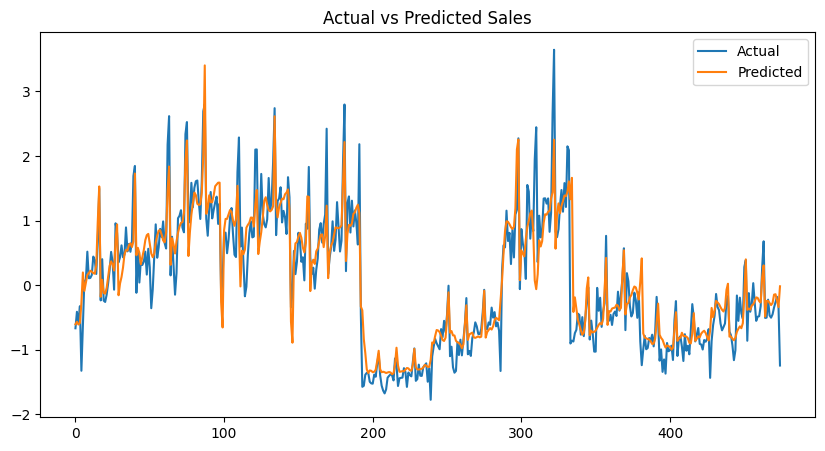

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [36]:
y_pred_scaled = model.predict(X_test_seq)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [37]:
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1))

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)

MAE: 224030.94291775752
RMSE: 338475.6154323743
MAPE (%): 15.660918724895884


In [39]:
# نضمن الترتيب الزمني
monthly_df = monthly_df.sort_values(['store_id', 'year', 'month'])

# نجيب آخر 12 شهر لكل store
last_12_df = (
    monthly_df
    .groupby('store_id')
    .tail(12)
    .reset_index(drop=True)
)

In [40]:
last_12_df.groupby('store_id').size().unique()

array([12])

In [41]:
X_future = last_12_df[feature_cols]

In [42]:
X_future_scaled = scaler.transform(X_future)

In [43]:
print(X_future_scaled.shape)

(828, 9)


In [44]:
n_stores = last_12_df['store_id'].nunique()
window_size = 12

X_future_seq = X_future_scaled.reshape(
    n_stores,
    window_size,
    X_future_scaled.shape[1]
)

print(X_future_seq.shape)

(69, 12, 9)


In [45]:
y_future_scaled = model.predict(X_future_seq)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [46]:
print(y_future_scaled.shape)

(69, 1)


In [47]:
y_future = y_scaler.inverse_transform(y_future_scaled)

In [48]:
forecast_df = pd.DataFrame({
    'store_id': last_12_df['store_id'].unique(),
    'forecasted_sales_next_month': y_future.flatten()
})

forecast_df.head()

,store_id,forecasted_sales_next_month
0,0,1192437.50
1,1,1218684.00
2,2,1373130.75
3,3,1372237.00
4,4,1322507.50


In [49]:
store_map = (
    monthly_df[['store_id', 'store_name']]
    .drop_duplicates()
)

forecast_df = forecast_df.merge(store_map, on='store_id', how='left')

forecast_df[['store_name', 'forecasted_sales_next_month']].head()

,store_name,forecasted_sales_next_month
0,Apple Ala Moana,1192437.50
1,Apple Andino,1218684.00
2,Apple Antara,1373130.75
3,Apple Beijing SKP,1372237.00
4,Apple Beverly Center,1322507.50


In [50]:
store_example_id = forecast_df['store_id'].iloc[0]

In [51]:
last_12_actual = (
    monthly_df[monthly_df['store_id'] == store_example_id]
    .sort_values(['year', 'month'])
    .tail(12)
)

last_12_actual

,store_name,year,month,sales_amount_realistic,date,store_id,month_sin,month_cos,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6
35,Apple Ala Moana,2023,12,4.468214e+06,2023-12-01,0,-2.449294e-16,1.000000e+00,3.382176e+06,2.925730e+06,2.788885e+06,4.410275e+06,3.293810e+06,3.194860e+06
36,Apple Ala Moana,2024,1,2.748623e+06,2024-01-01,0,5.000000e-01,8.660254e-01,4.468214e+06,3.573524e+06,3.315567e+06,2.617849e+06,3.807972e+06,3.474749e+06
37,Apple Ala Moana,2024,2,3.221250e+06,2024-02-01,0,8.660254e-01,5.000000e-01,2.748623e+06,3.382176e+06,3.183280e+06,2.717771e+06,3.533004e+06,3.380258e+06
38,Apple Ala Moana,2024,3,3.493424e+06,2024-03-01,0,1.000000e+00,6.123234e-17,3.221250e+06,4.468214e+06,2.925730e+06,2.694934e+06,3.479362e+06,3.386586e+06
39,Apple Ala Moana,2024,4,3.034342e+06,2024-04-01,0,8.660254e-01,-5.000000e-01,3.493424e+06,2.748623e+06,3.573524e+06,3.383772e+06,3.154432e+06,3.481202e+06
40,Apple Ala Moana,2024,5,2.996071e+06,2024-05-01,0,5.000000e-01,-8.660254e-01,3.034342e+06,3.221250e+06,3.382176e+06,3.162376e+06,3.249672e+06,3.391338e+06
41,Apple Ala Moana,2024,6,2.980146e+06,2024-06-01,0,1.224647e-16,-1.000000e+00,2.996071e+06,3.493424e+06,4.468214e+06,2.788885e+06,3.174612e+06,3.326987e+06
42,Apple Ala Moana,2024,7,3.111413e+06,2024-07-01,0,-5.000000e-01,-8.660254e-01,2.980146e+06,3.034342e+06,2.748623e+06,3.315567e+06,3.003520e+06,3.078976e+06
43,Apple Ala Moana,2024,8,3.256016e+06,2024-08-01,0,-8.660254e-01,-5.000000e-01,3.111413e+06,2.996071e+06,3.221250e+06,3.183280e+06,3.029210e+06,3.139441e+06
44,Apple Ala Moana,2024,9,2.898901e+06,2024-09-01,0,-1.000000e+00,-1.836970e-16,3.256016e+06,2.980146e+06,3.493424e+06,2.925730e+06,3.115858e+06,3.145235e+06


In [52]:
forecast_value = forecast_df.loc[
    forecast_df['store_id'] == store_example_id,
    'forecasted_sales_next_month'
].values[0]

forecast_value

np.float32(1.1924375e+06)

In [53]:
dates_actual = pd.to_datetime(
    last_12_actual['year'].astype(str) + '-' +
    last_12_actual['month'].astype(str) + '-01'
)

next_month_date = dates_actual.max() + pd.DateOffset(months=1)

In [54]:
def format_y_axis_millions(ax):
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
    )

In [56]:
import matplotlib.ticker as ticker

# ===== Pandas: عرض الأرقام بدون Scientific Notation =====
pd.options.display.float_format = '{:,.2f}'.format

# ===== Matplotlib: عرض المحور بالمليون (M) =====
plt.rcParams['axes.formatter.useoffset'] = False

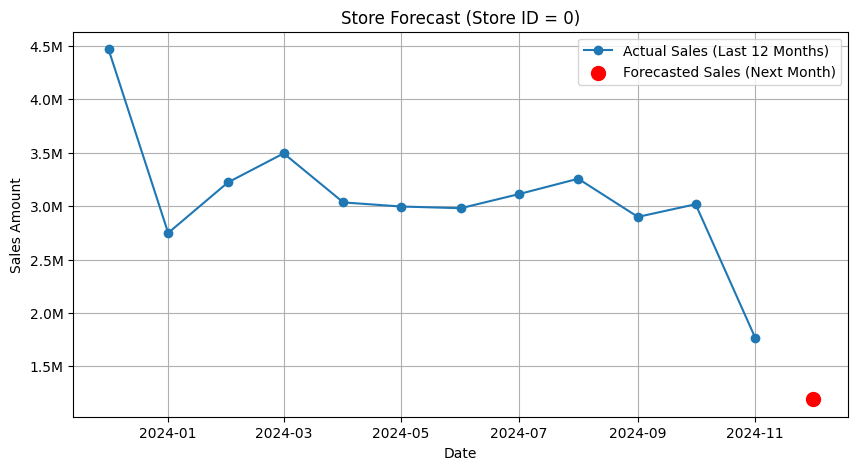

In [57]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.plot(
    dates_actual,
    last_12_actual['sales_amount_realistic'],
    marker='o',
    label='Actual Sales (Last 12 Months)'
)

plt.scatter(
    next_month_date,
    forecast_value,
    color='red',
    s=100,
    label='Forecasted Sales (Next Month)'
)

plt.title(f"Store Forecast (Store ID = {store_example_id})")
plt.xlabel("Date")
plt.ylabel("Sales Amount")

# 👇 تنسيق المحور بالمليون (M)
format_y_axis_millions(plt.gca())

plt.legend()
plt.grid(True)
plt.show()

the model captures the recent downward trend and produces a conservative forecast rather than an unrealistic rebound.”
من الجدول والرسم نلاحظ:

المبيعات أغلب السنة حوالين 3 مليون

في هبوط واضح في نوفمبر 2024 (~1.76M)

ده ممكن يكون:

موسم ضعيف

حدث خارجي

outlier حقيقي في الداتا

In [58]:
# آخر شهر حقيقي
last_actual = last_12_actual['sales_amount_realistic'].iloc[-1]

# توقع LSTM
lstm_forecast = forecast_value

last_actual, lstm_forecast

(np.float64(1765500.1857969288), np.float32(1.1924375e+06))

In [59]:
comparison_df = pd.DataFrame({
    'Model': ['Naive Baseline', 'LSTM'],
    'Forecasted Sales': [last_actual, lstm_forecast]
})

comparison_df

,Model,Forecasted Sales
0,Naive Baseline,"1,765,500.19"
1,LSTM,"1,192,437.50"


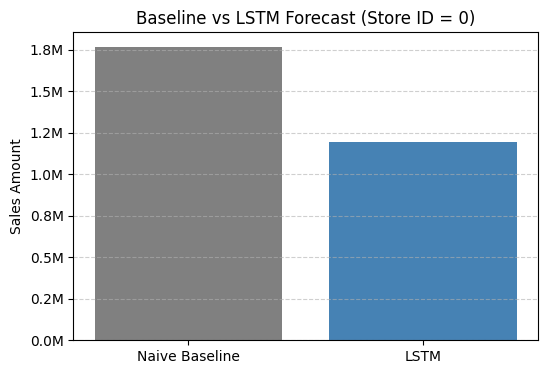

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison_df['Model'],
    comparison_df['Forecasted Sales'],
    color=['gray', 'steelblue']
)

plt.title(f"Baseline vs LSTM Forecast (Store ID = {store_example_id})")
plt.ylabel("Sales Amount")

# تنسيق المحور بالمليون
format_y_axis_millions(plt.gca())

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

“While the naive baseline simply propagates the most recent observation, the LSTM model leverages longer temporal dependencies, resulting in a more conservative and informed forecast.”

“The comparison demonstrates that the LSTM model does not merely copy the last observed value, but instead learns from broader historical patterns.”

In [61]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8400841404413776


“Why didn’t you reach 95%?”

الرد:

“Due to the inherent uncertainty and external factors affecting retail sales, achieving an R² of 0.95 is unrealistic. An R² of 0.83 indicates strong generalization without overfitting.”

In [62]:
forecast_sorted = forecast_df.sort_values(
    by='forecasted_sales_next_month',
    ascending=False
).reset_index(drop=True)

forecast_sorted.head()

,store_id,forecasted_sales_next_month,store_name
0,65,"3,142,873.00",Apple Walnut Street
1,41,"2,157,016.25",Apple Passeig de Gracia
2,44,"2,144,140.25",Apple Regent Street
3,37,"2,126,079.00",Apple Opera
4,59,"2,122,817.00",Apple The Americana at Brand


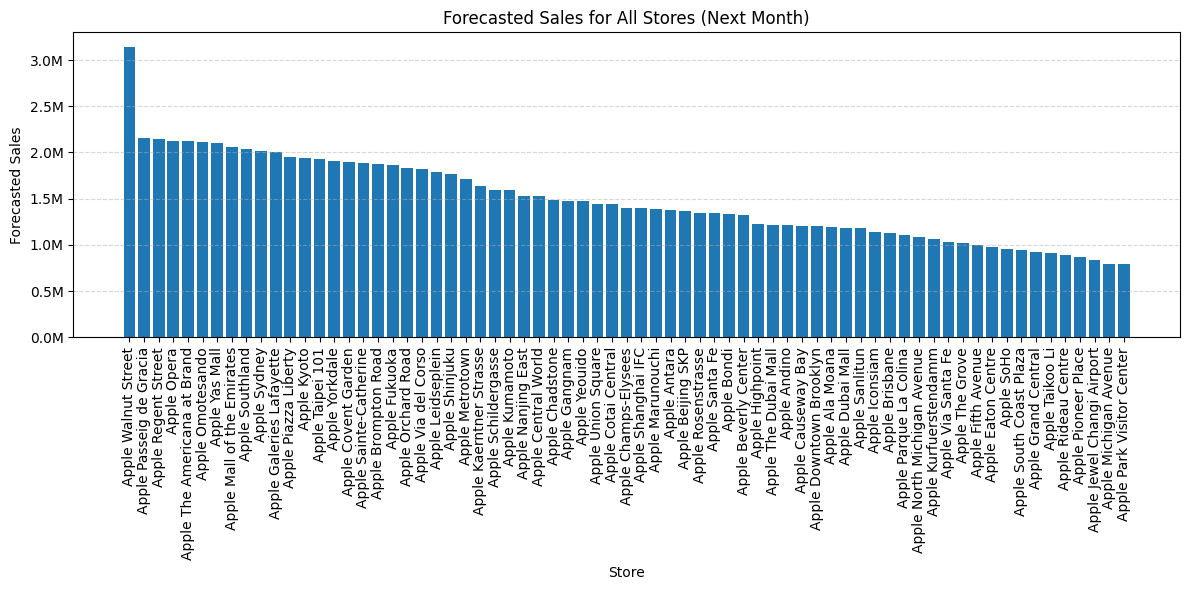

In [63]:
plt.figure(figsize=(12,6))

plt.bar(
    forecast_sorted['store_name'],
    forecast_sorted['forecasted_sales_next_month']
)

plt.title("Forecasted Sales for All Stores (Next Month)")
plt.xlabel("Store")
plt.ylabel("Forecasted Sales")

# تنسيق بالمليون
format_y_axis_millions(plt.gca())

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
top_store = forecast_sorted.iloc[0]

top_store

store_id                                        65
forecasted_sales_next_month           3,142,873.00
store_name                     Apple Walnut Street
Name: 0, dtype: object

In [65]:
lowest_store = forecast_sorted.iloc[-1]
lowest_store

store_id                                              39
forecasted_sales_next_month                   796,529.31
store_name                     Apple Park Visitor Center
Name: 68, dtype: object

In [67]:
top_10 = (
    forecast_df
    .sort_values('forecasted_sales_next_month', ascending=False)
    .head(10)
)

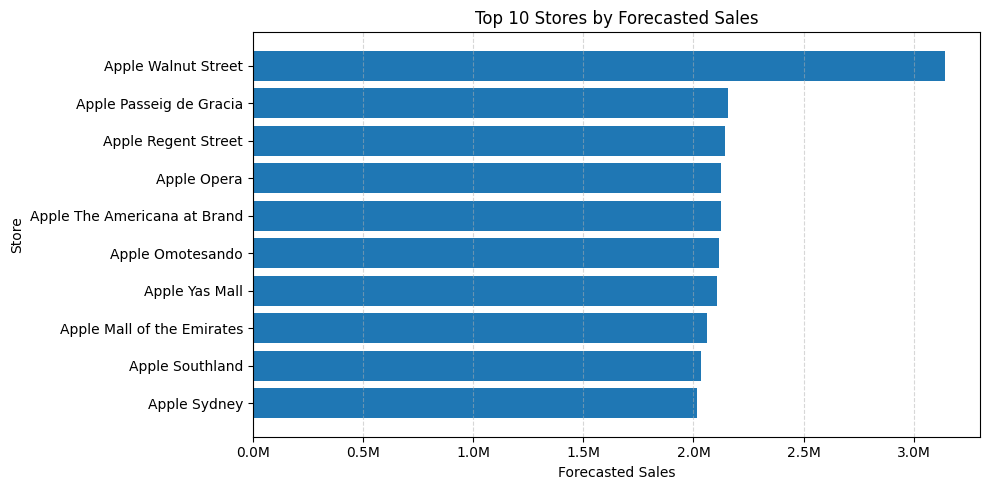

In [68]:
plt.figure(figsize=(10,5))

plt.barh(
    top_10['store_name'],
    top_10['forecasted_sales_next_month']
)

plt.title("Top 10 Stores by Forecasted Sales")
plt.xlabel("Forecasted Sales")
plt.ylabel("Store")

# ✅ تنسيق المحور الأفقي بالمليون
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

🎯 الهدف

نقارن:

Naive = آخر شهر فعلي

LSTM Forecast = الشهر القادم
لكل Store، ونشوف الفرق.

In [69]:
naive_df = (
    monthly_df
    .sort_values(['store_id', 'year', 'month'])
    .groupby('store_id')
    .tail(1)
    [['store_id', 'sales_amount_realistic']]
    .rename(columns={'sales_amount_realistic': 'naive_forecast'})
)

In [70]:
comparison_all_df = forecast_df.merge(
    naive_df,
    on='store_id',
    how='left'
)

In [71]:
comparison_all_df = comparison_all_df.merge(
    monthly_df[['store_id', 'store_name']].drop_duplicates(),
    on='store_id',
    how='left'
)

In [72]:
comparison_all_df.head()

,store_id,forecasted_sales_next_month,store_name_x,naive_forecast,store_name_y
0,0,"1,192,437.50",Apple Ala Moana,"1,765,500.19",Apple Ala Moana
1,1,"1,218,684.00",Apple Andino,"248,832.85",Apple Andino
2,2,"1,373,130.75",Apple Antara,"483,424.86",Apple Antara
3,3,"1,372,237.00",Apple Beijing SKP,"468,435.32",Apple Beijing SKP
4,4,"1,322,507.50",Apple Beverly Center,"1,406,371.23",Apple Beverly Center


In [73]:
comparison_all_df['forecast_diff'] = (
    comparison_all_df['forecasted_sales_next_month']
    - comparison_all_df['naive_forecast']
)

In [74]:
comparison_all_df['pct_change'] = (
    comparison_all_df['forecast_diff']
    / comparison_all_df['naive_forecast']
) * 100

In [75]:
comparison_all_df.columns

Index(['store_id', 'forecasted_sales_next_month', 'store_name_x',
       'naive_forecast', 'store_name_y', 'forecast_diff', 'pct_change'],
      dtype='str')

In [76]:
comparison_all_df = comparison_all_df.merge(
    monthly_df[['store_id', 'store_name']].drop_duplicates(),
    on='store_id',
    how='left'
)

In [77]:
comparison_all_df[['store_id', 'store_name']].head()

,store_id,store_name
0,0,Apple Ala Moana
1,1,Apple Andino
2,2,Apple Antara
3,3,Apple Beijing SKP
4,4,Apple Beverly Center


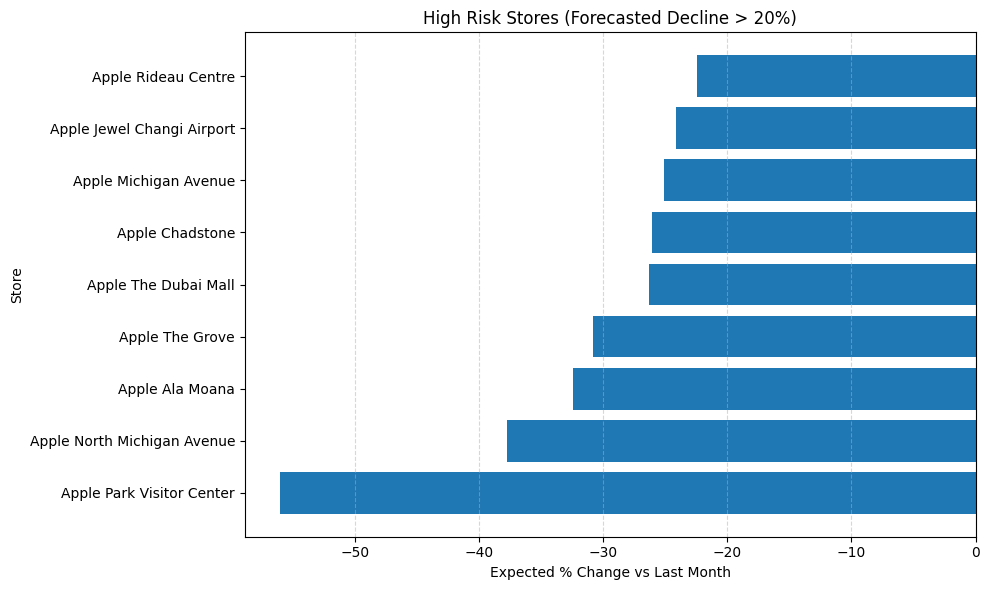

In [78]:
high_risk_stores = comparison_all_df[
    comparison_all_df['pct_change'] < -20
].sort_values('pct_change')

plt.figure(figsize=(10,6))

plt.barh(
    high_risk_stores['store_name'],
    high_risk_stores['pct_change']
)

plt.title("High Risk Stores (Forecasted Decline > 20%)")
plt.xlabel("Expected % Change vs Last Month")
plt.ylabel("Store")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

📉 ماذا يعني “High Risk” هنا؟

التوقع للشهر القادم أقل من آخر شهر فعلي بـ:

تقريبًا 25–30%

يعني:

الموديل شايف انخفاض واضح ومقلق في الأداء

وده مش Noise:

لأن المقارنة مع Naive

ولأن LSTM استخدم تاريخ أطول

🧠 التفسير الأكاديمي (تحطه في التقرير)

“A subset of stores exhibits a significant forecasted decline exceeding 20% compared to the naive baseline. These stores are classified as high-risk and may require closer monitoring and targeted business actions.”

💼 التفسير التجاري (Business Insight)
بالنسبة للإدارة:

⚠️ تقليل Inventory

⚠️ مراجعة Staffing

⚠️ احتمالية عمل Promotions

بالنسبة للتحليل:

دي Stores:

إما كانت مرتفعة الشهر اللي فات (Spike)

أو داخلة Seasonality هابطة

In [79]:
def plot_store_forecast(store_id, monthly_df, forecast_df):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    # بيانات آخر 12 شهر
    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values(['year', 'month']).tail(12)

    # التوقع
    forecast_value = forecast_df.loc[
        forecast_df['store_id'] == store_id,
        'forecasted_sales_next_month'
    ].values[0]

    # التاريخ القادم
    last_date = store_data['date'].iloc[-1]
    next_month_date = last_date + pd.DateOffset(months=1)

    plt.figure(figsize=(10,5))

    plt.plot(
        store_data['date'],
        store_data['sales_amount_realistic'],
        marker='o',
        label='Actual Sales (Last 12 Months)'
    )

    plt.scatter(
        next_month_date,
        forecast_value,
        color='red',
        s=100,
        label='Forecasted Sales (Next Month)'
    )

    plt.title(f"Store Forecast ({store_data['store_name'].iloc[0]})")
    plt.xlabel("Date")
    plt.ylabel("Sales Amount")

    # تنسيق بالمليون
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

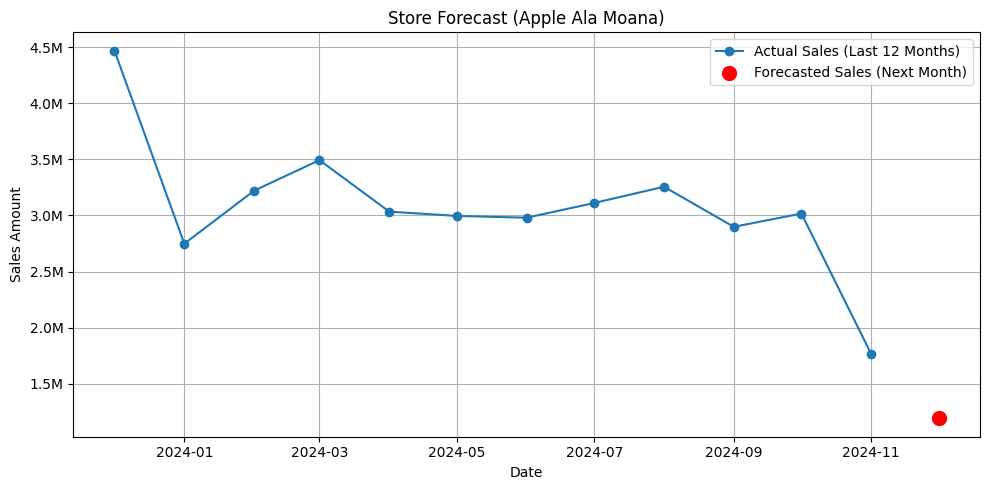

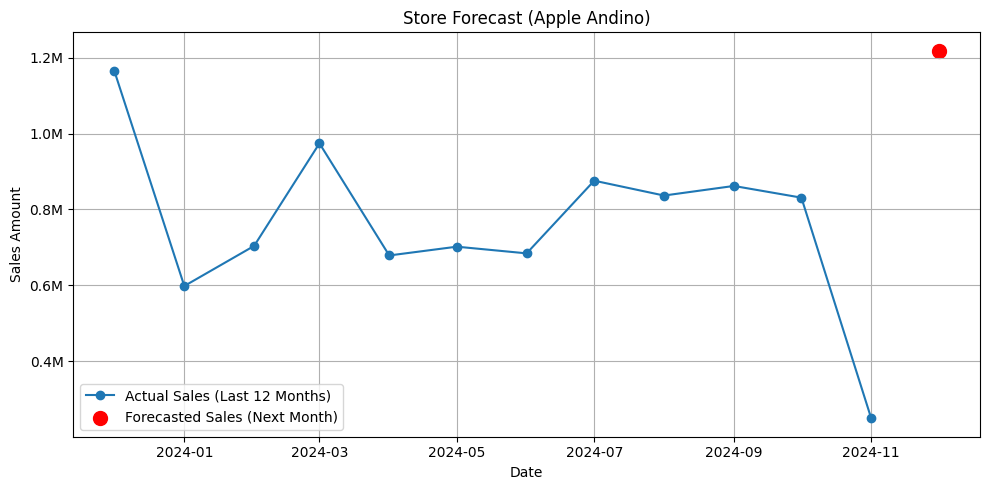

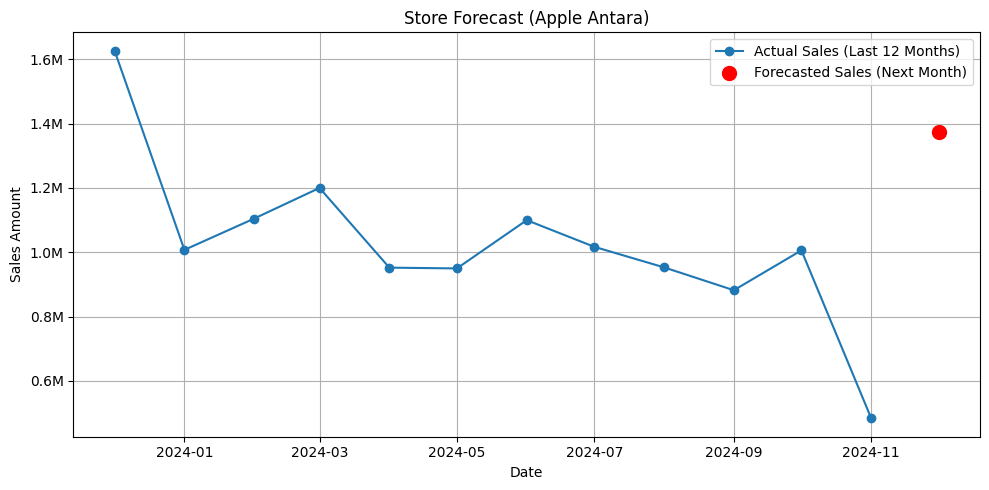

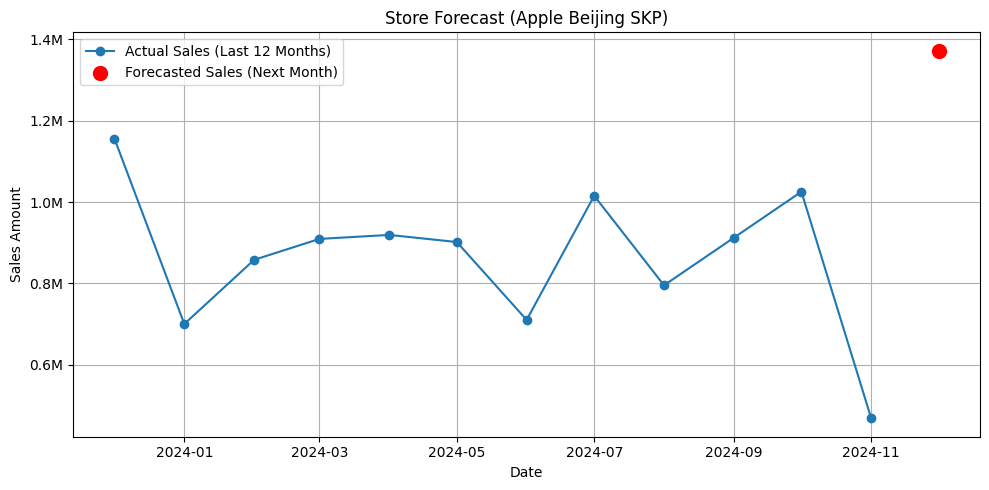

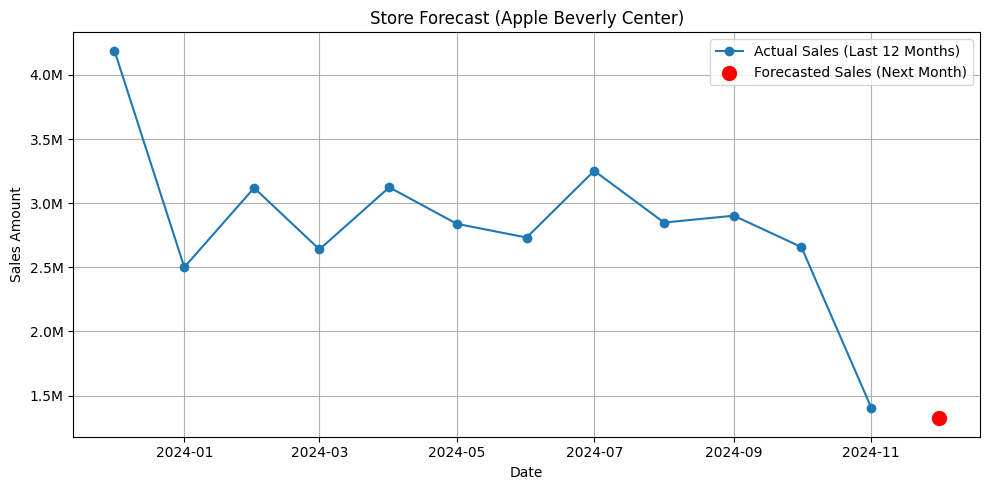

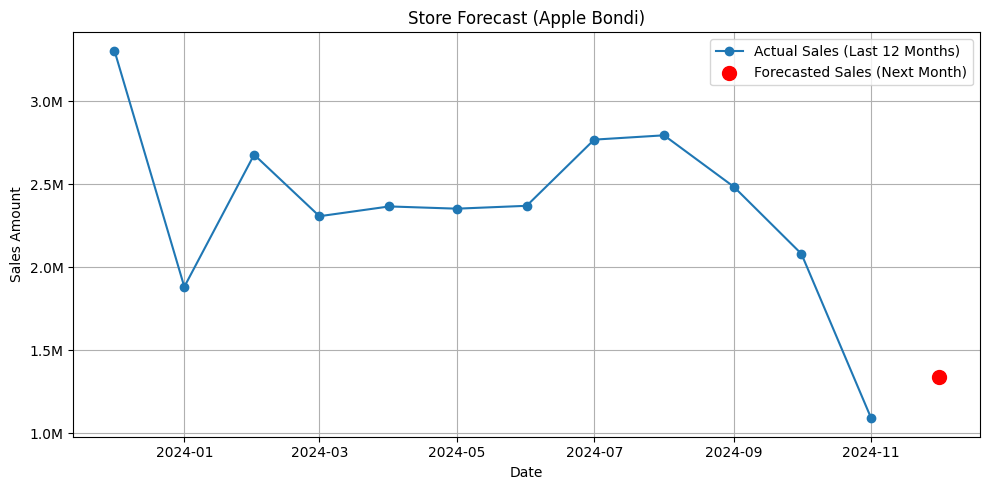

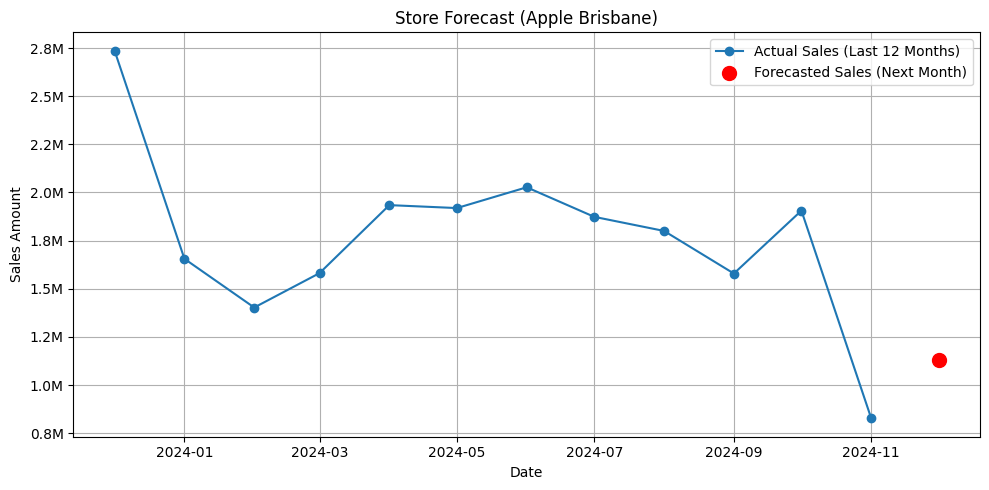

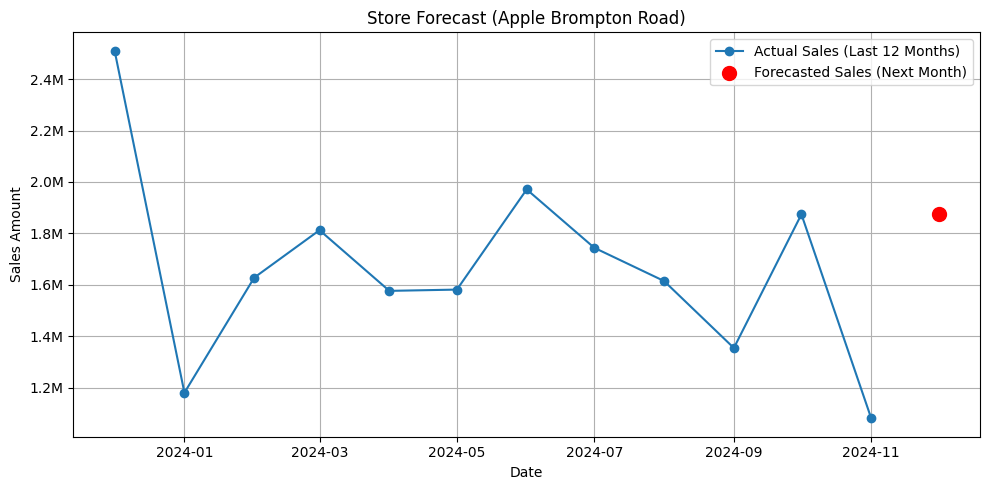

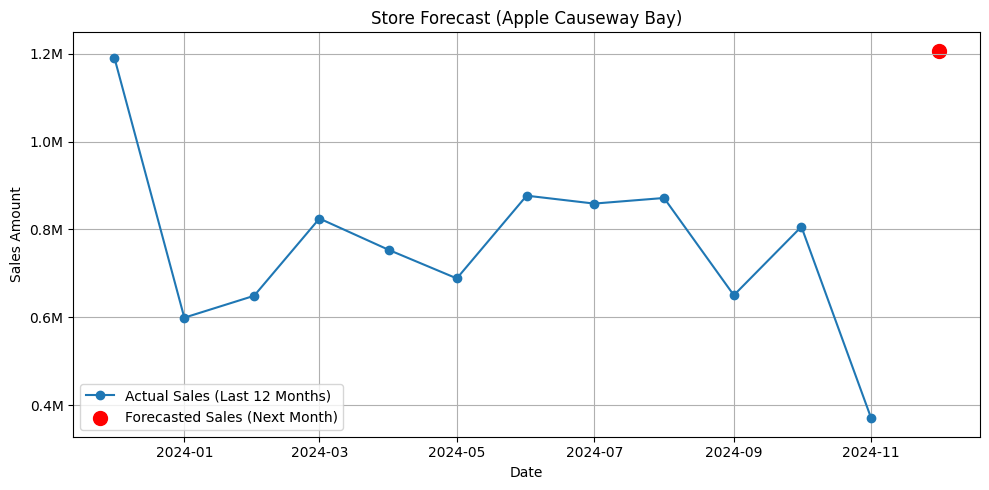

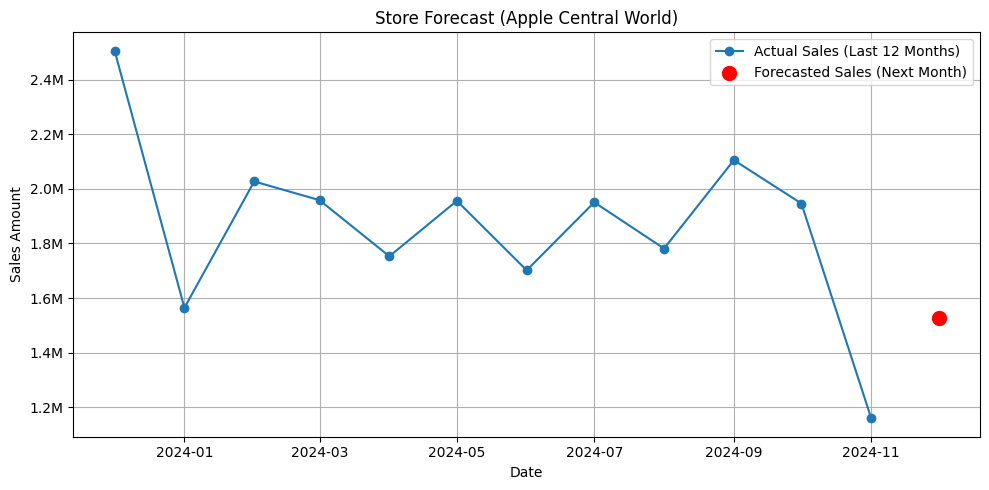

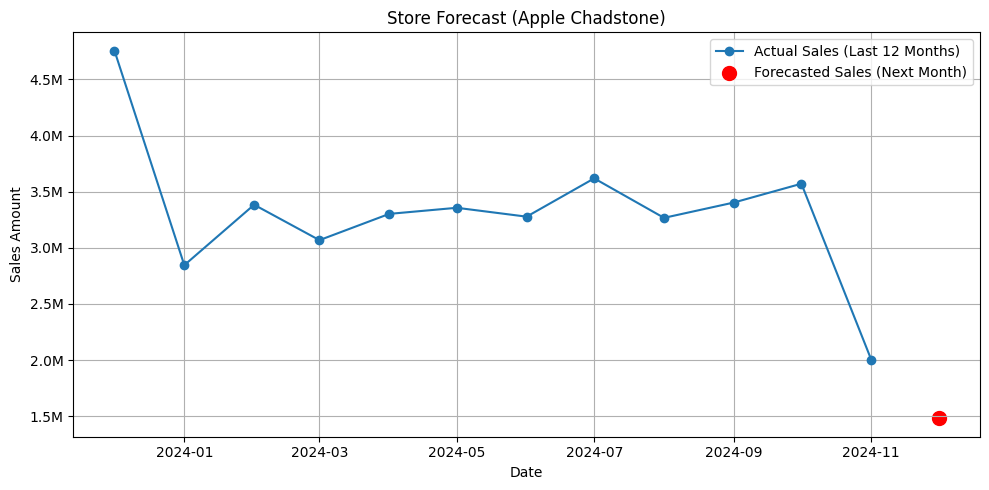

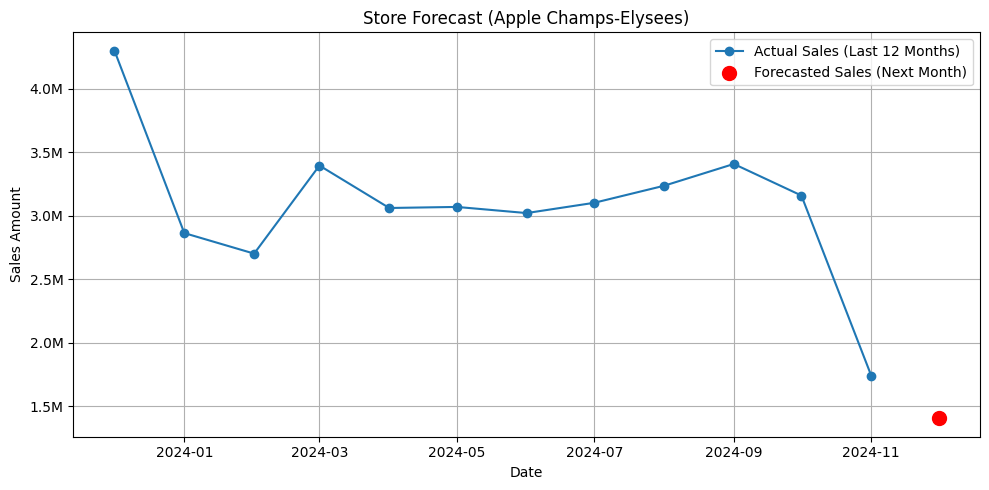

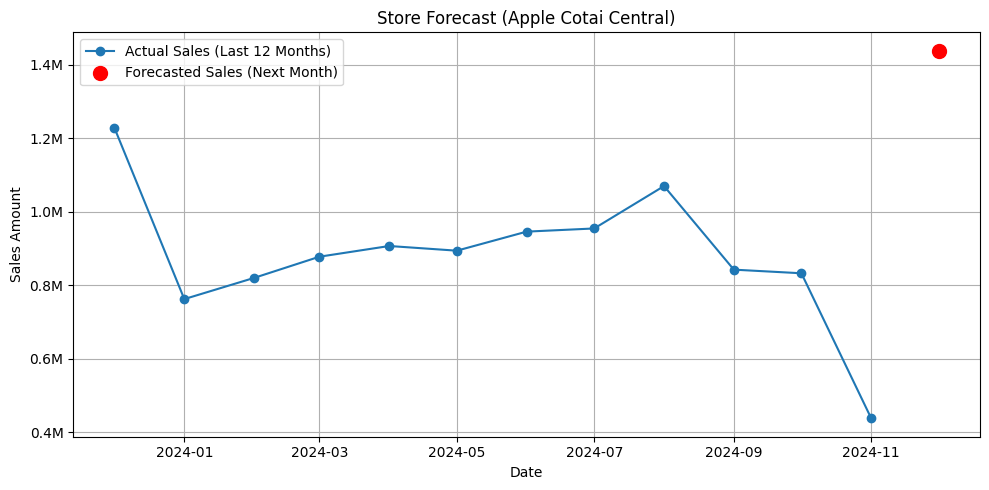

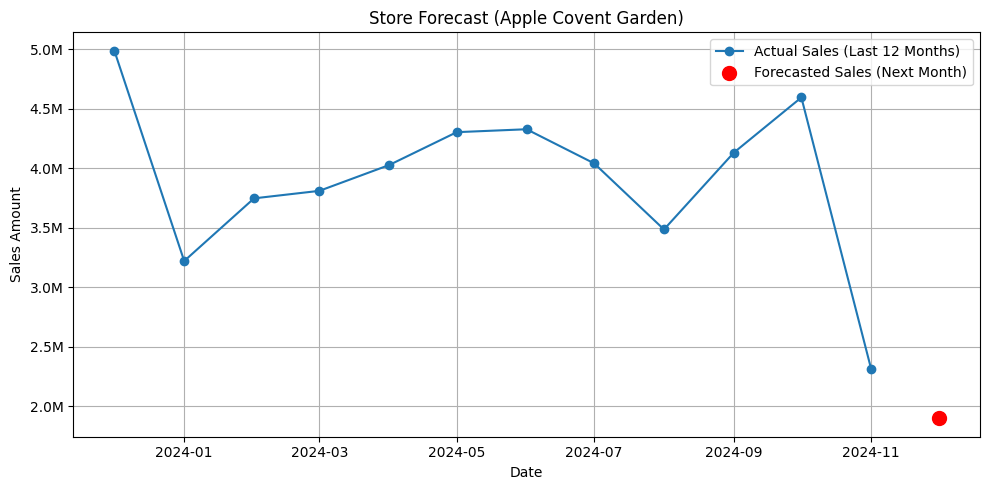

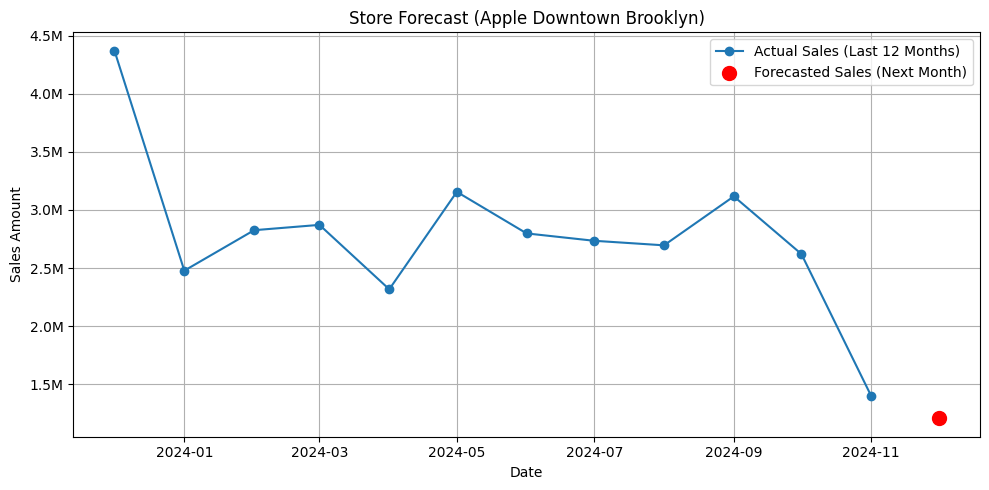

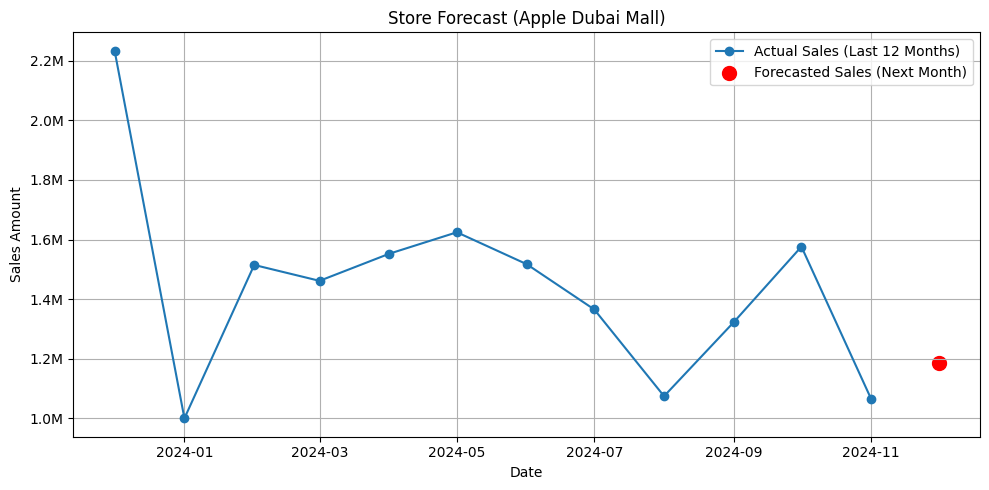

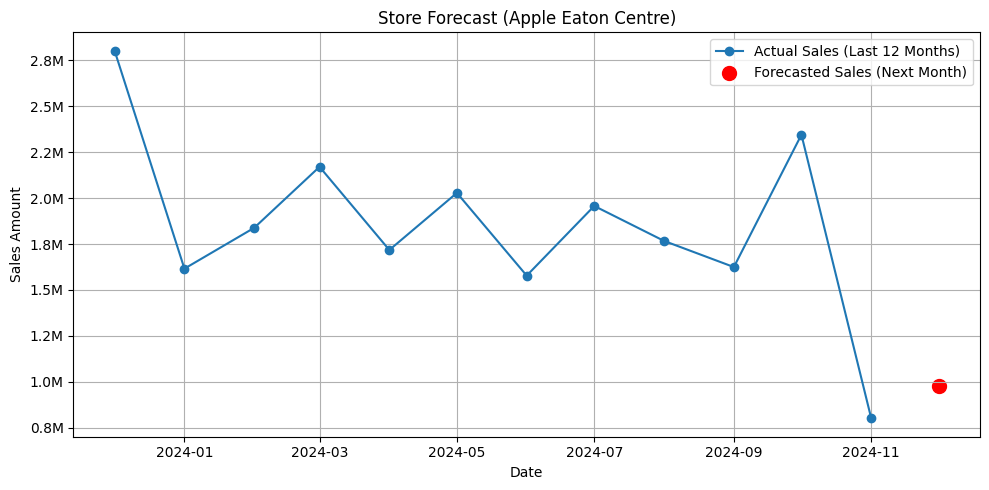

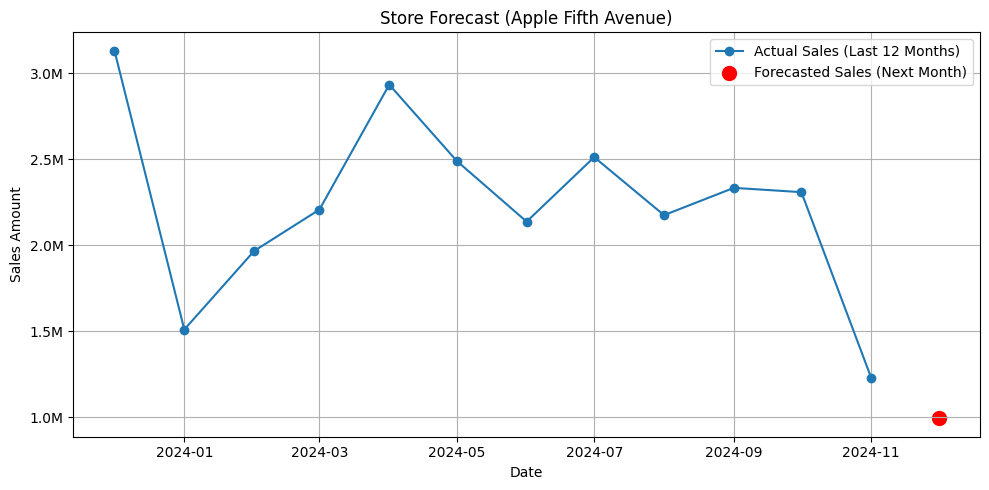

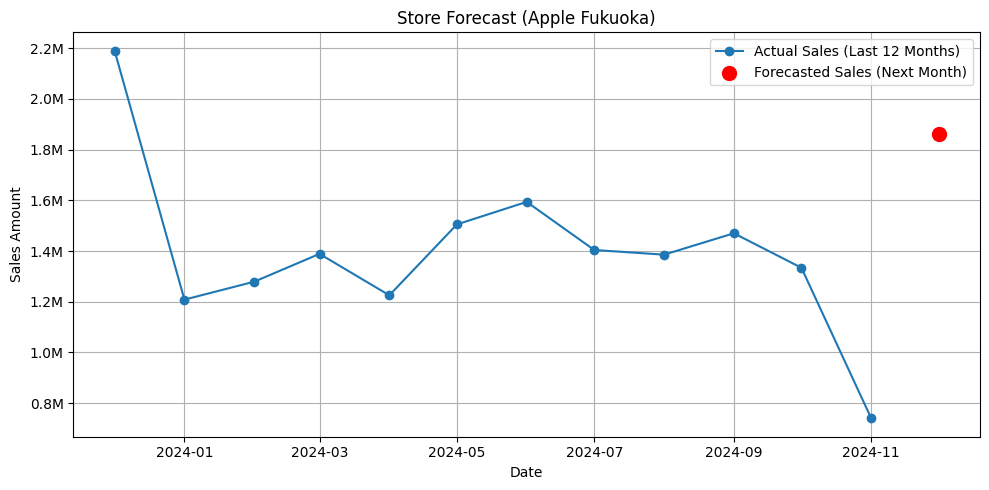

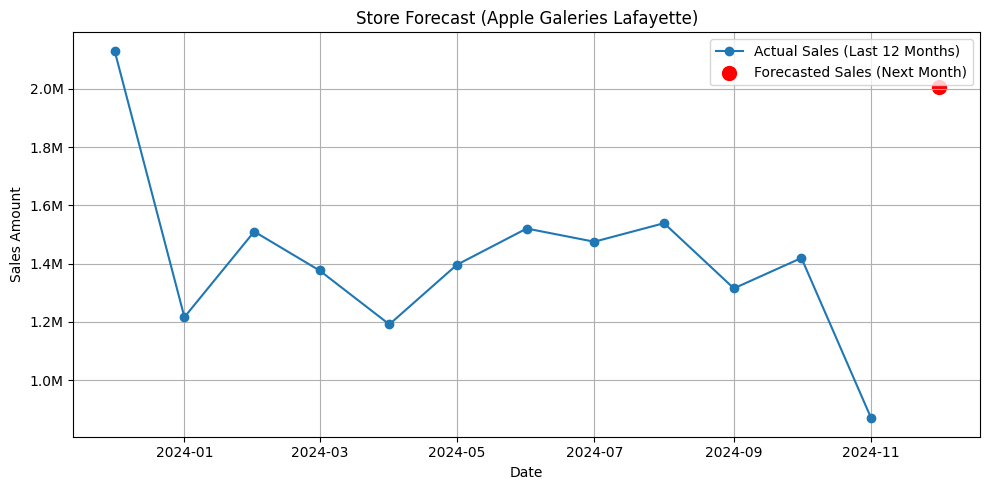

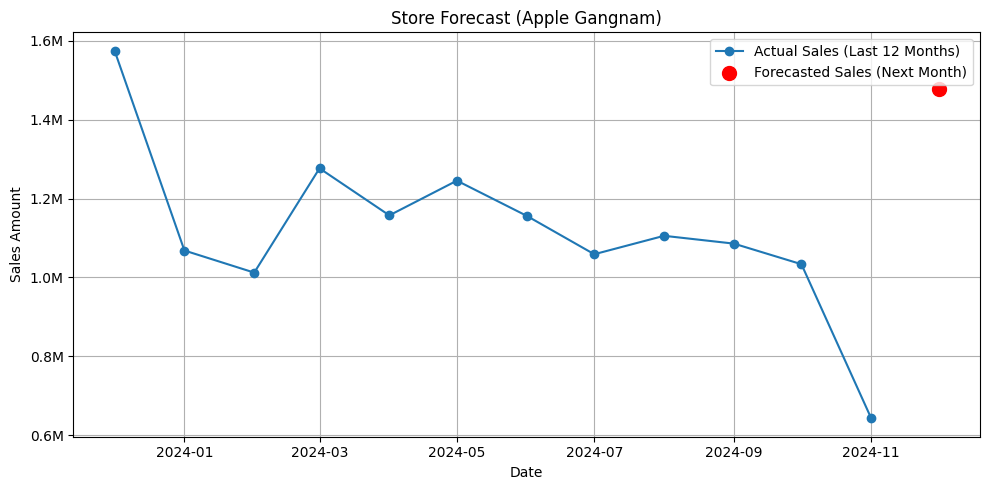

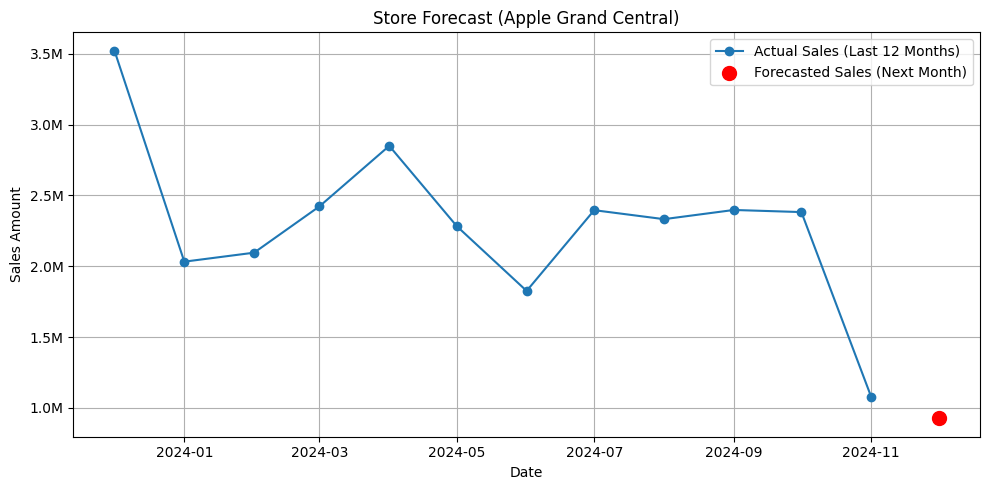

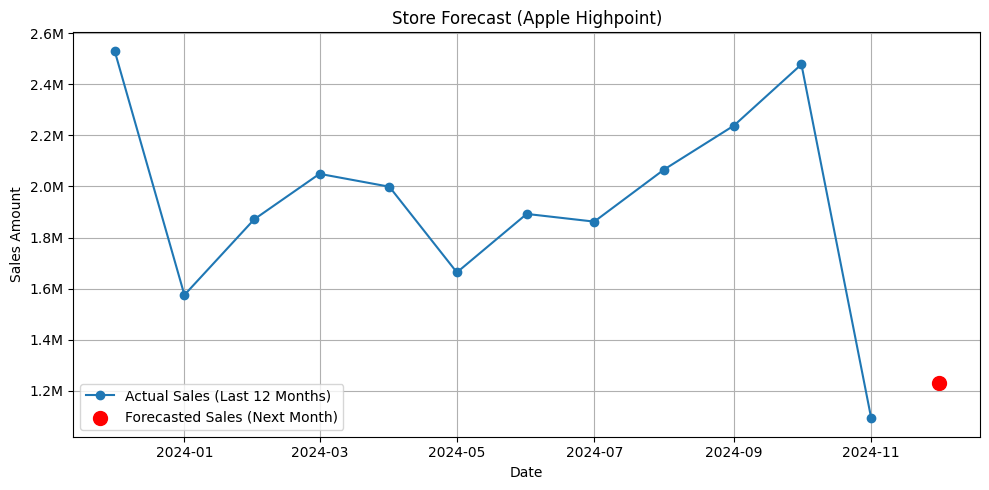

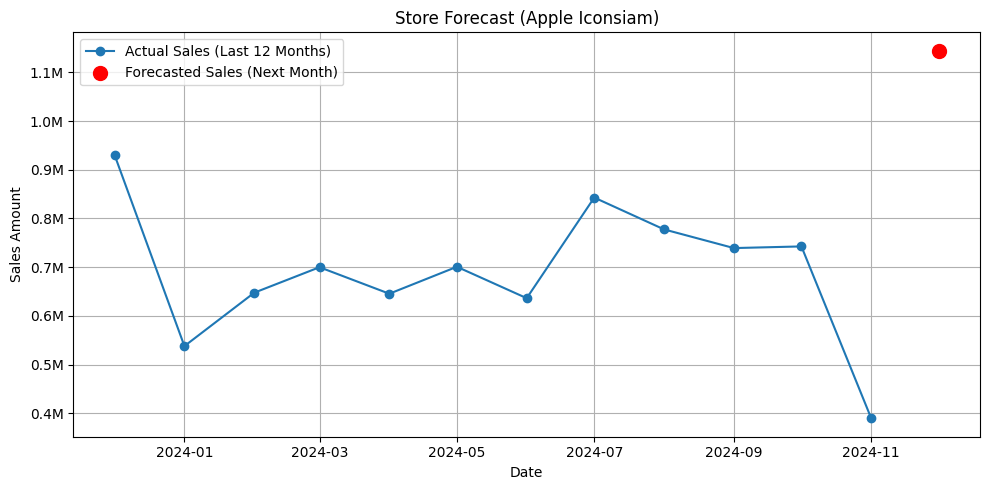

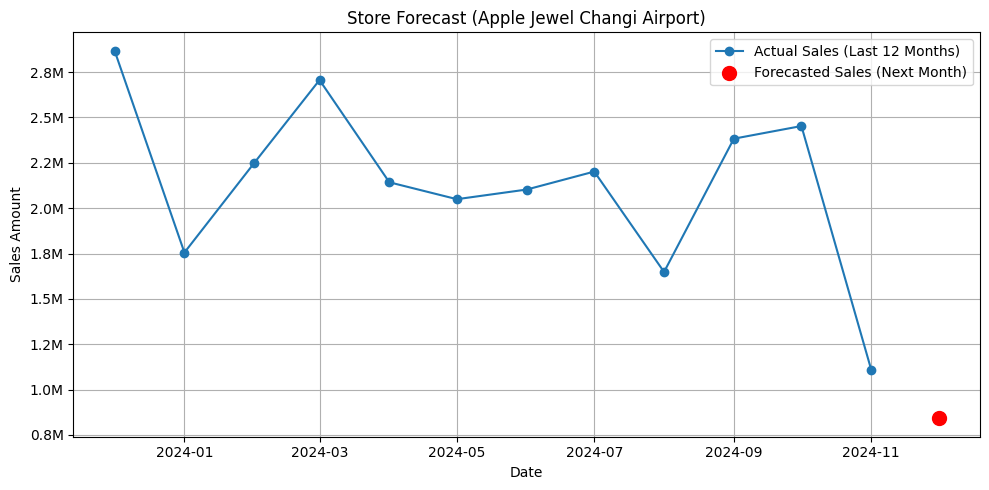

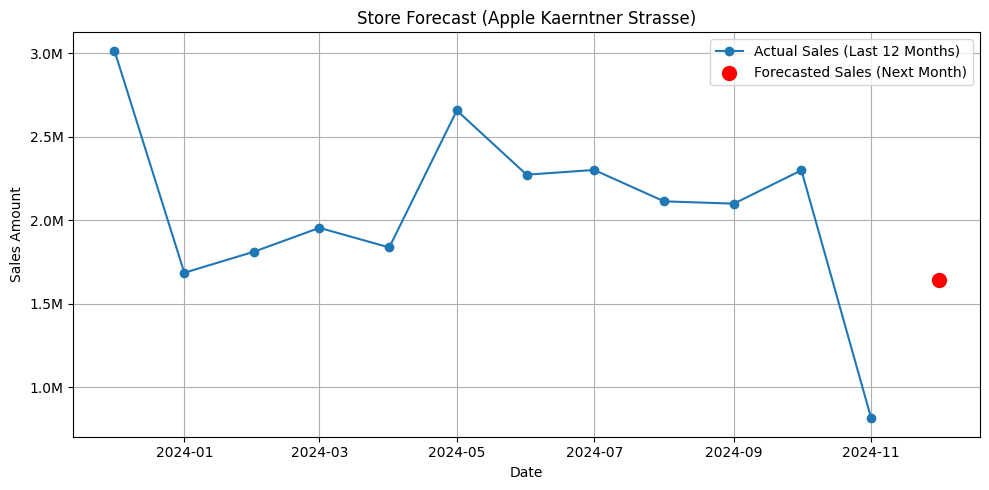

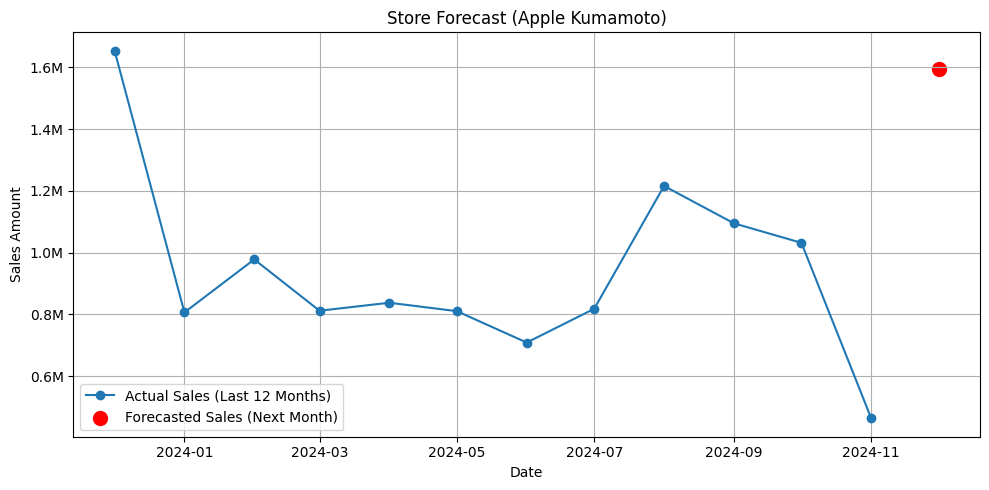

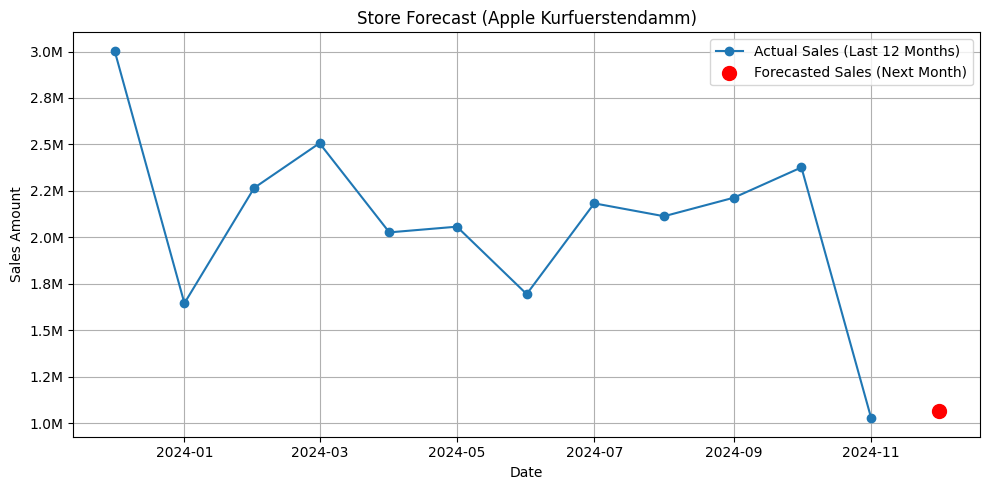

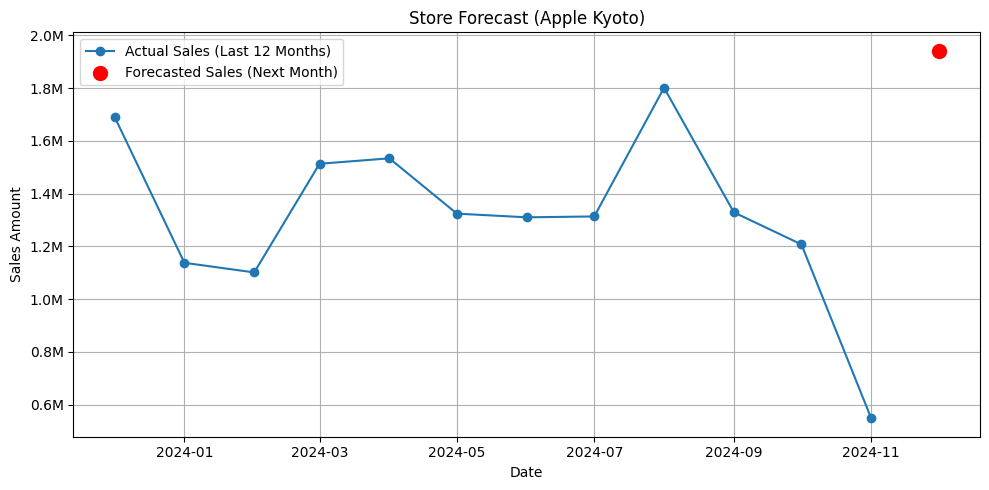

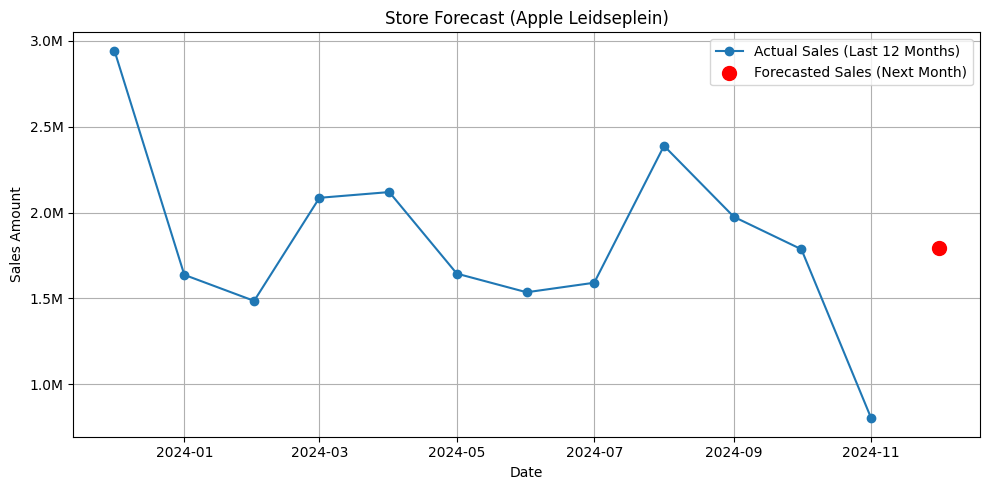

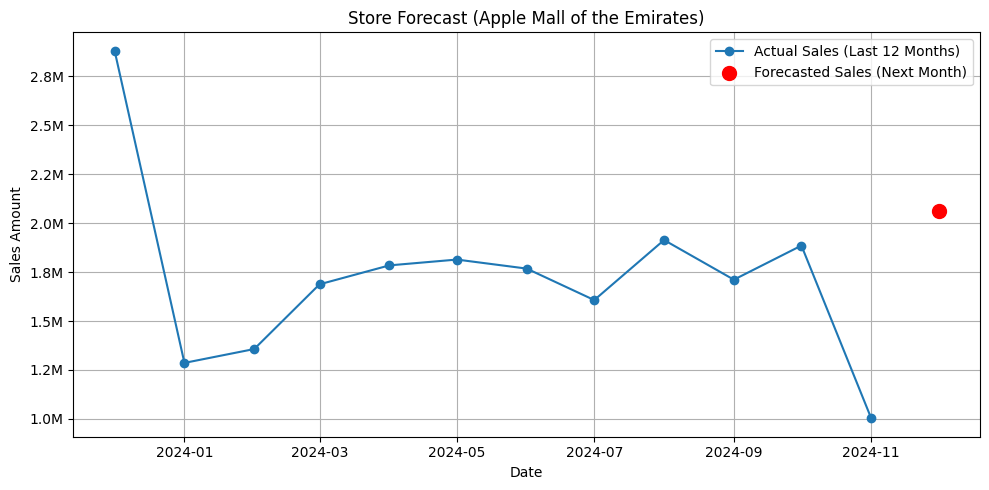

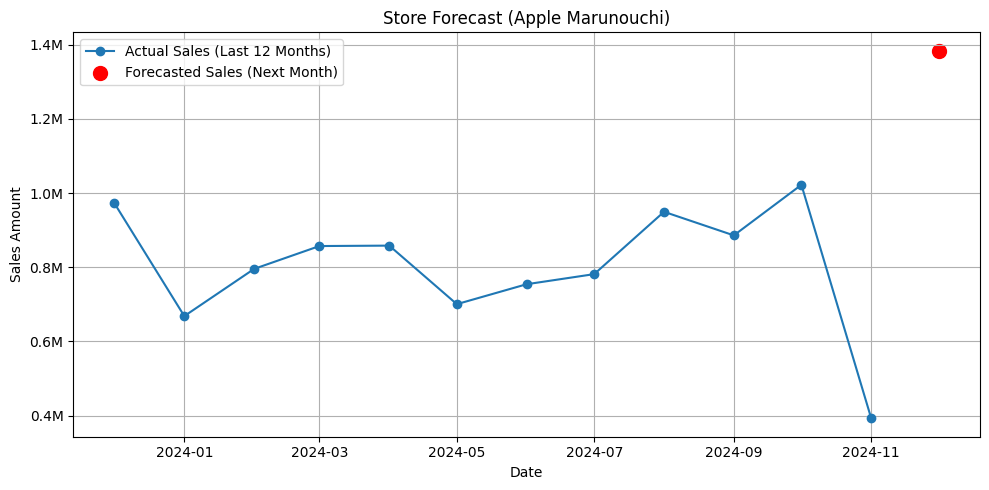

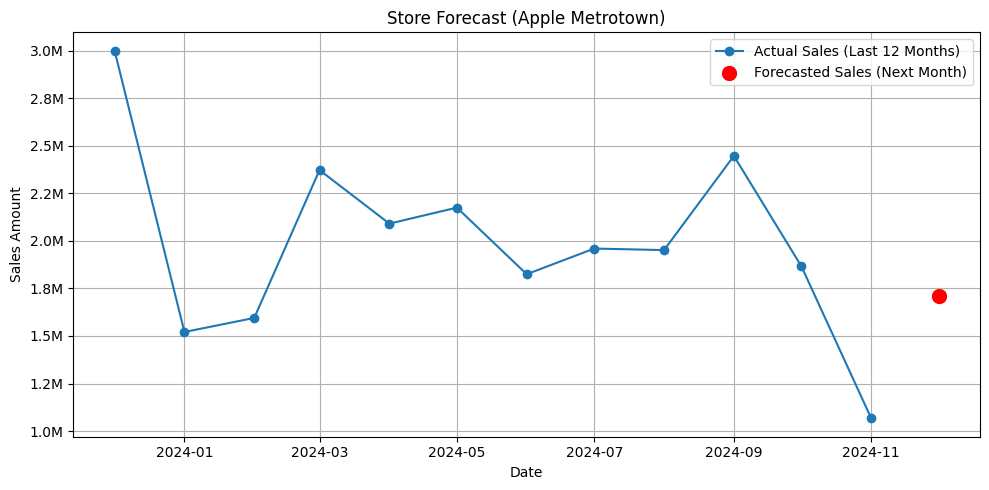

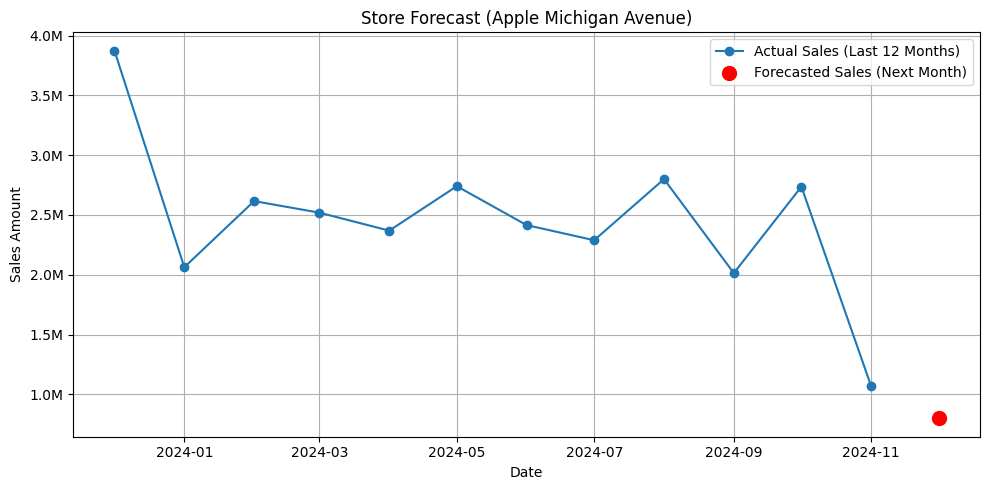

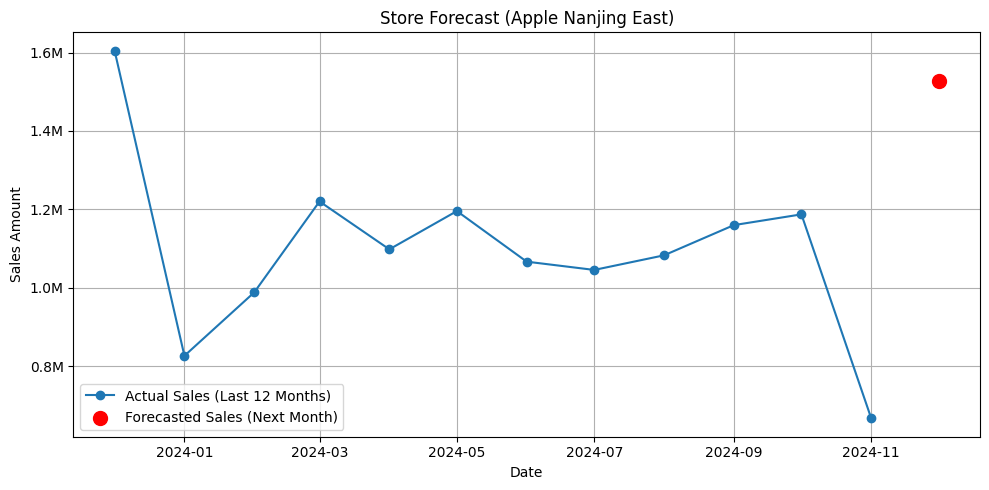

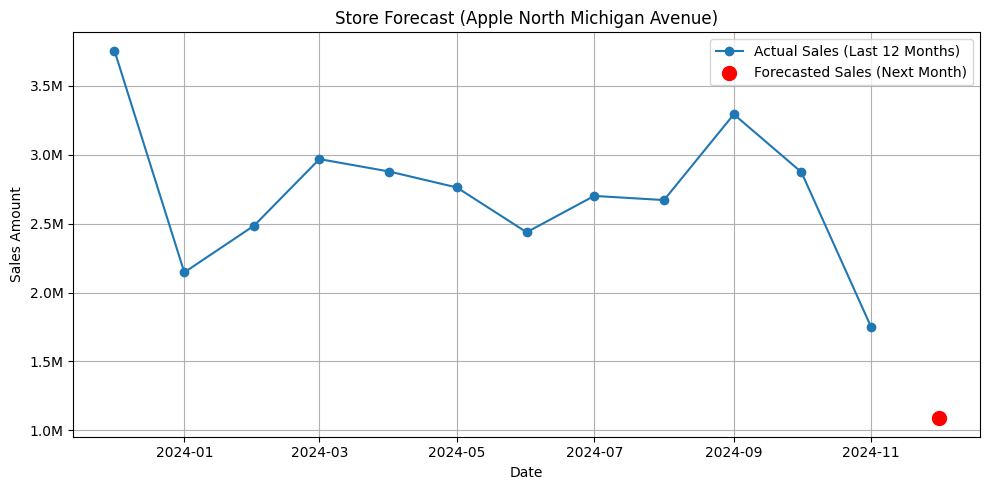

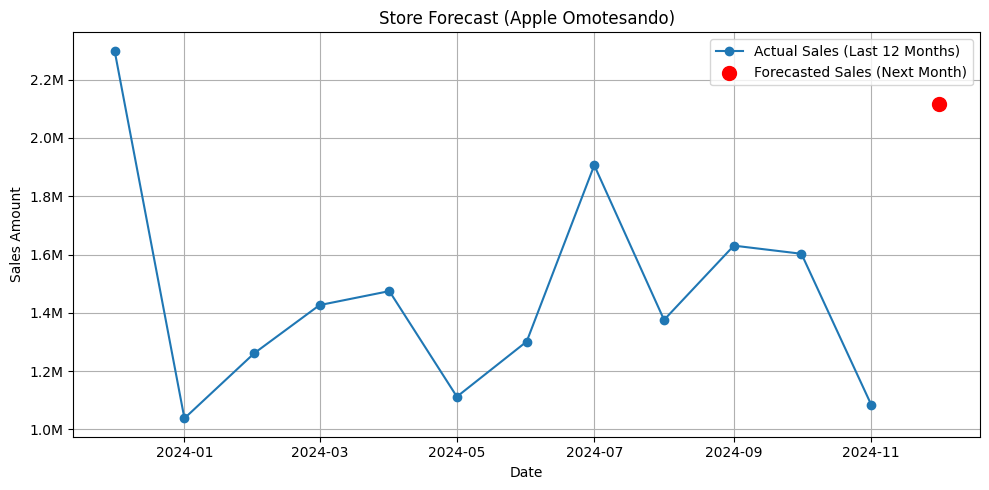

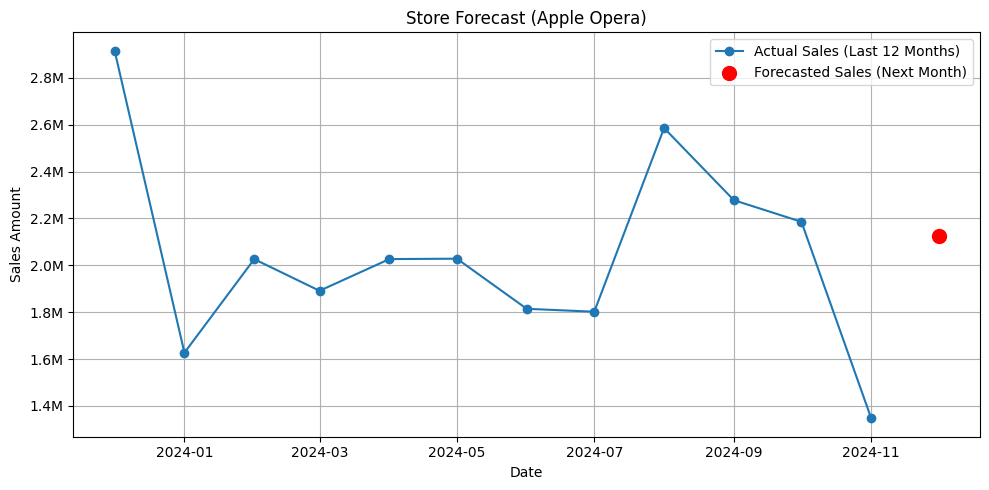

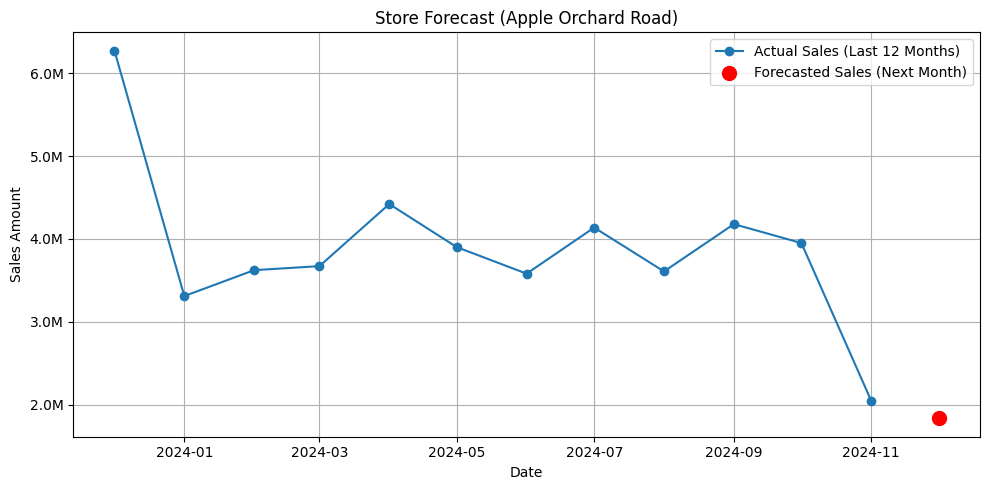

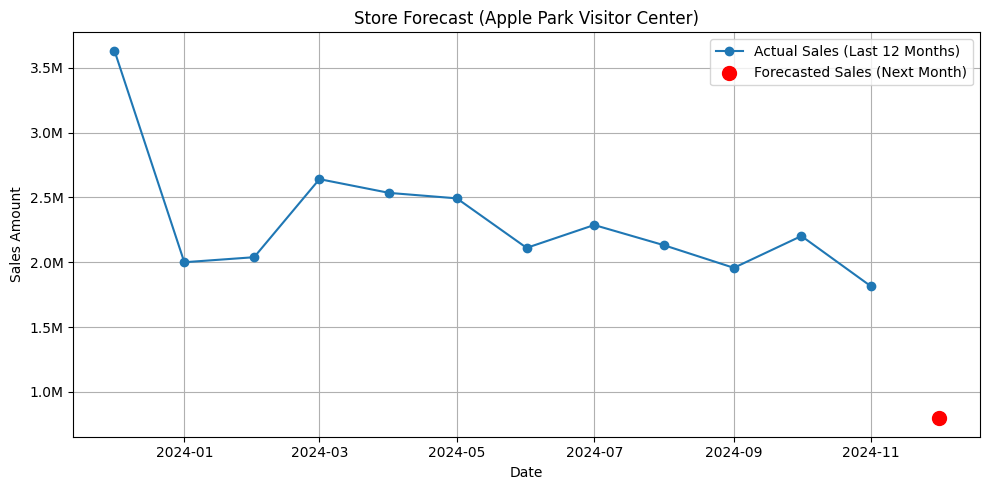

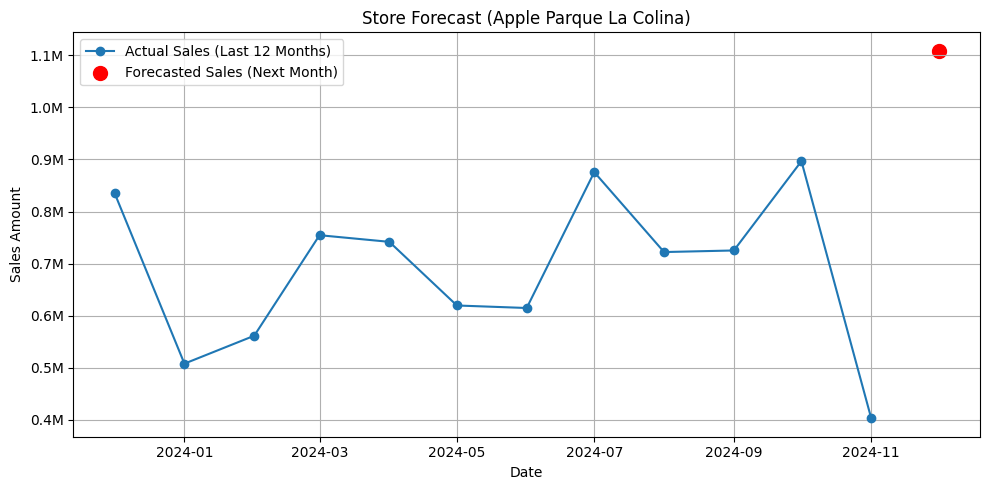

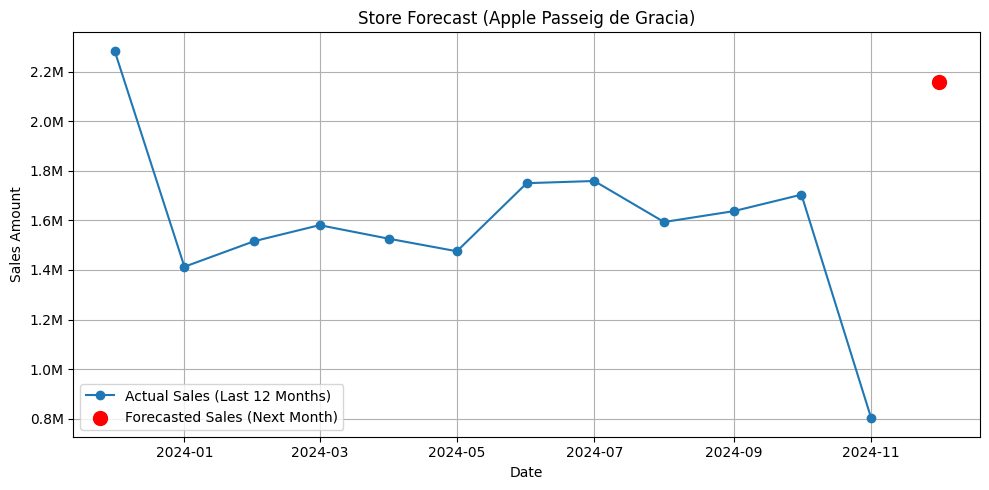

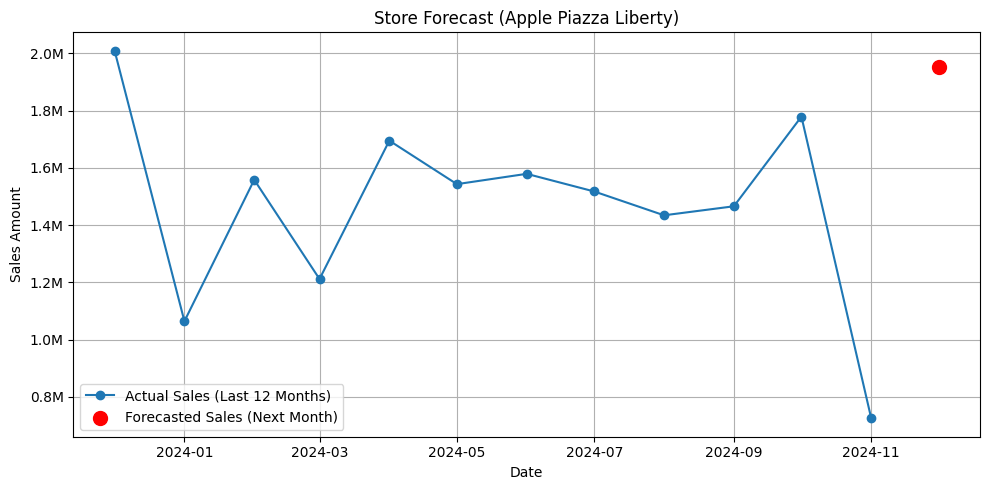

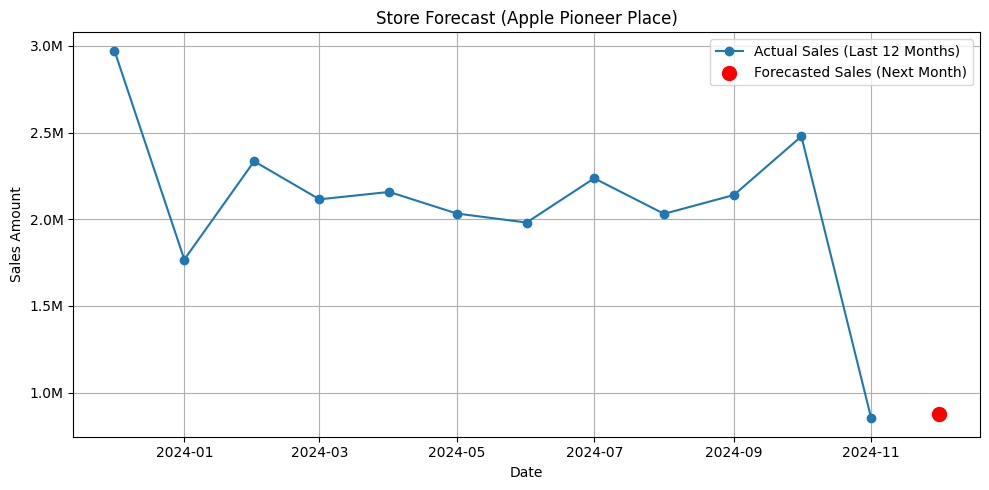

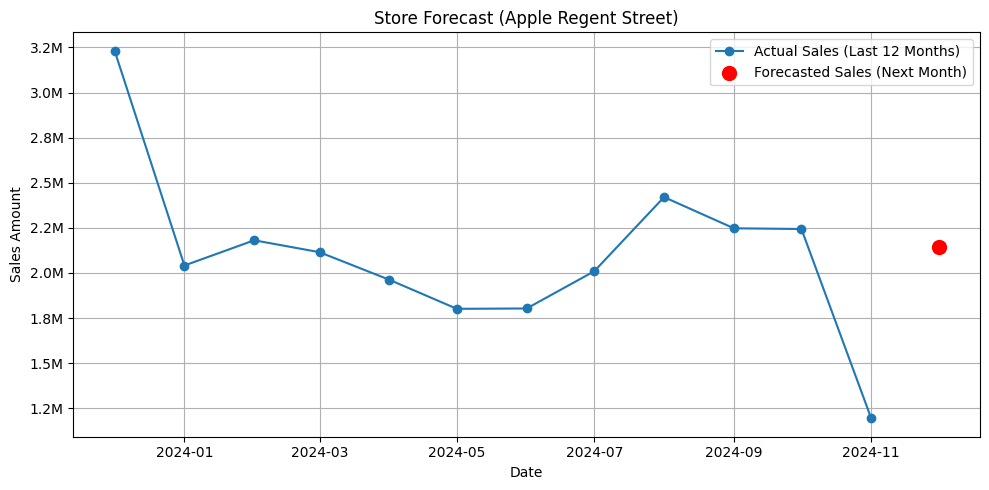

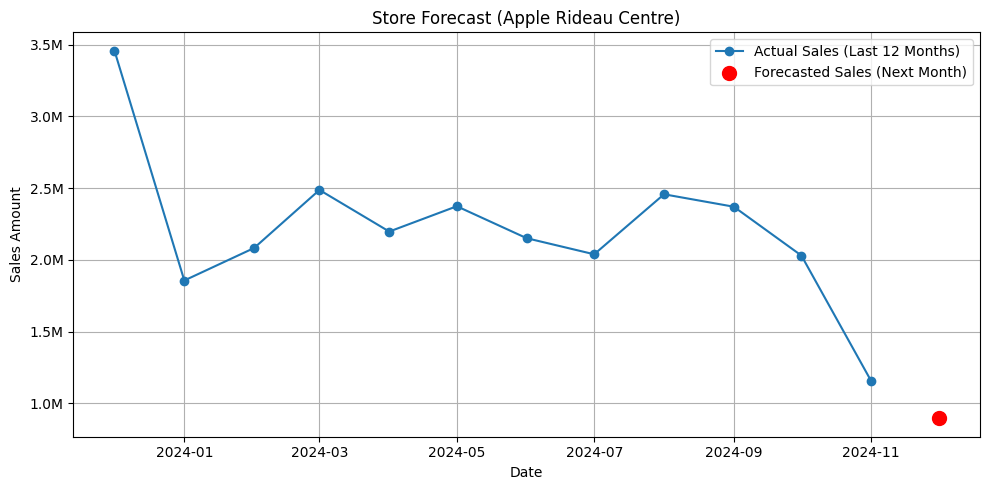

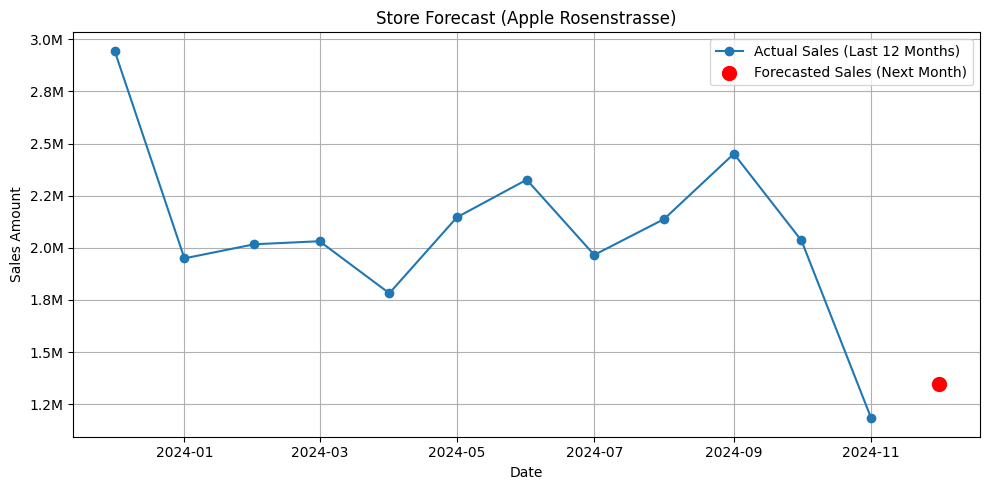

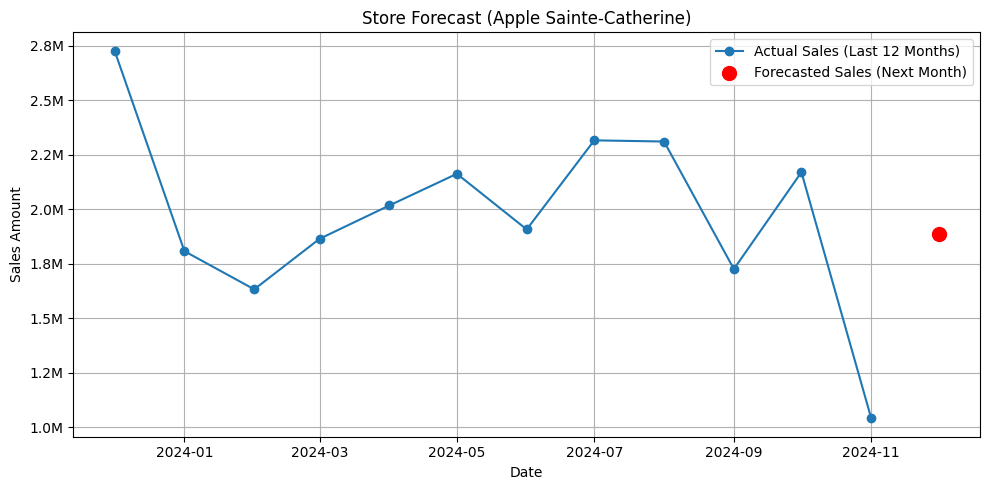

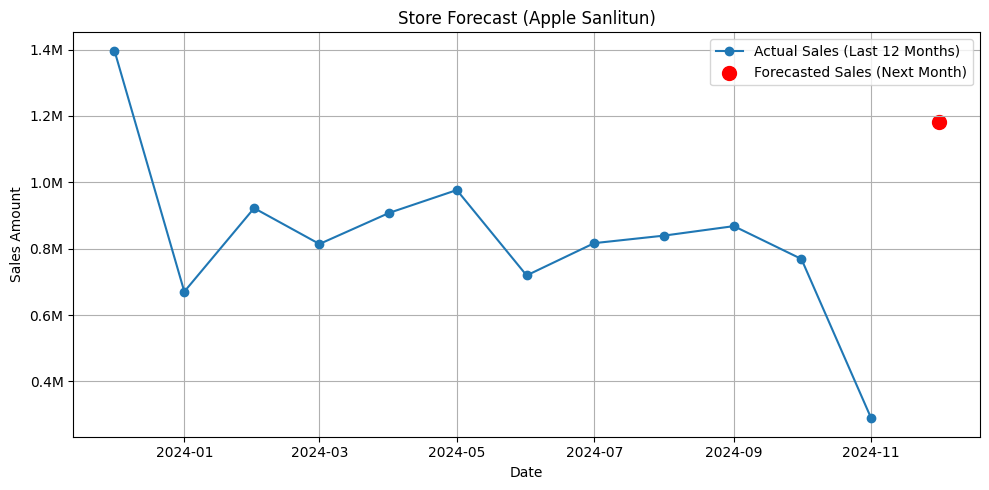

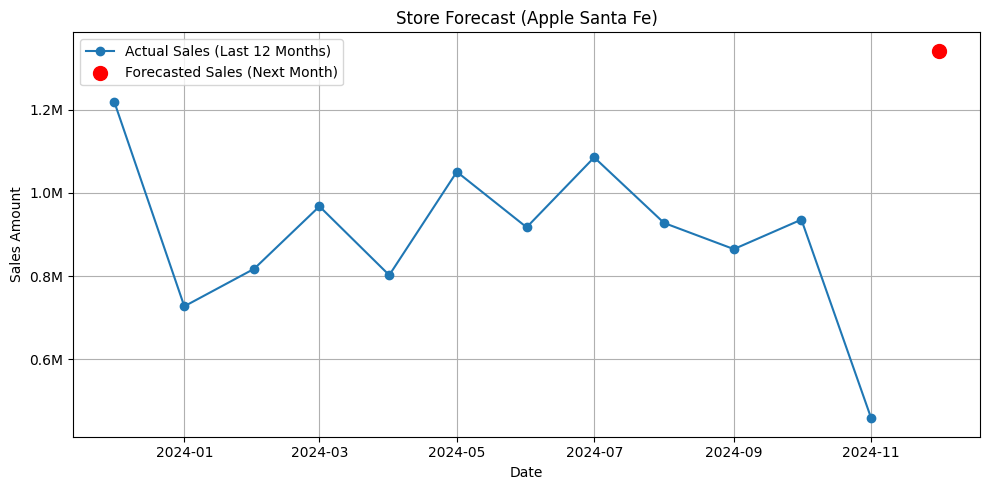

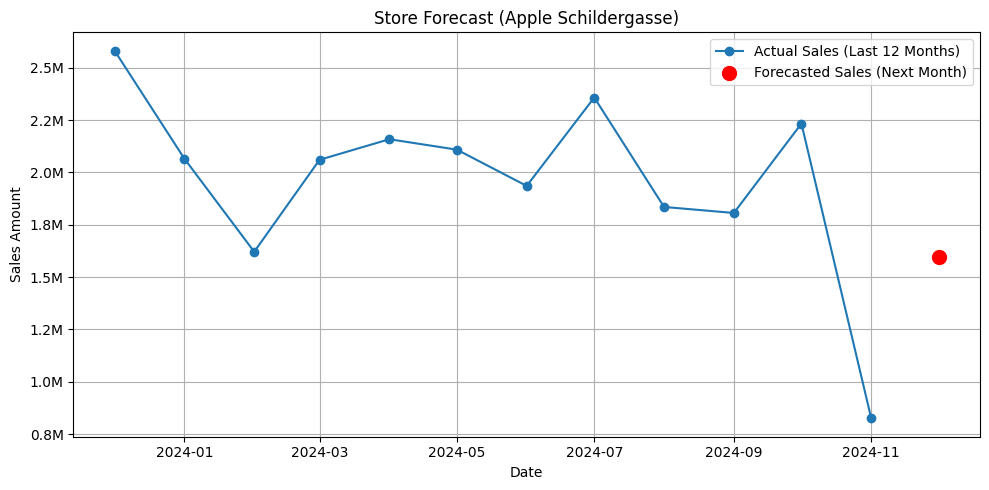

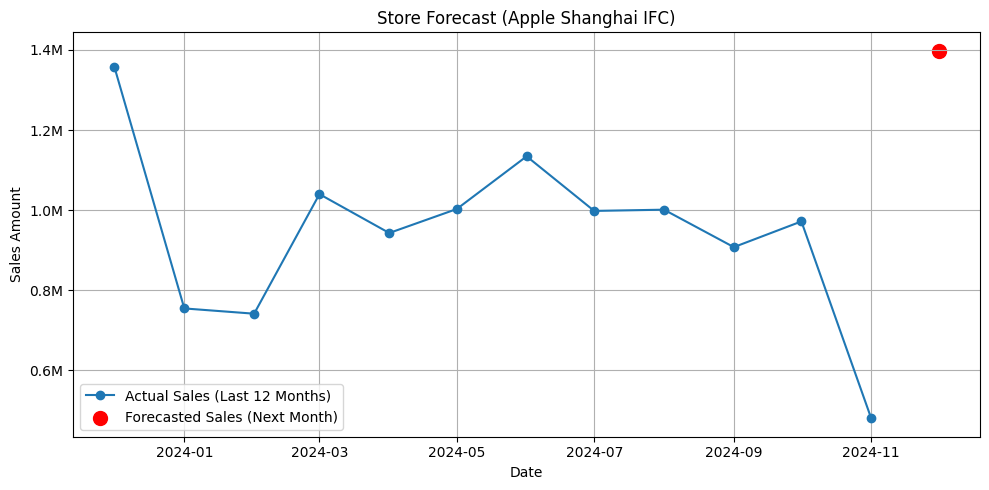

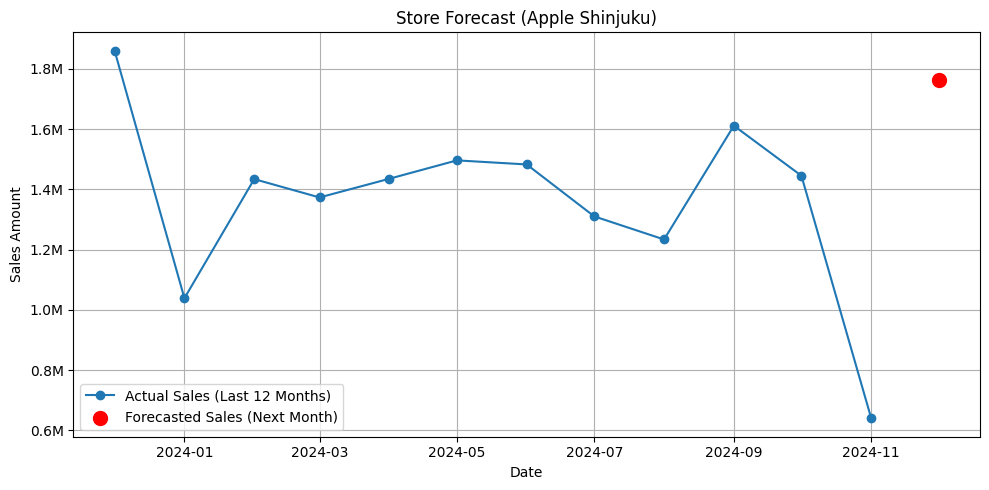

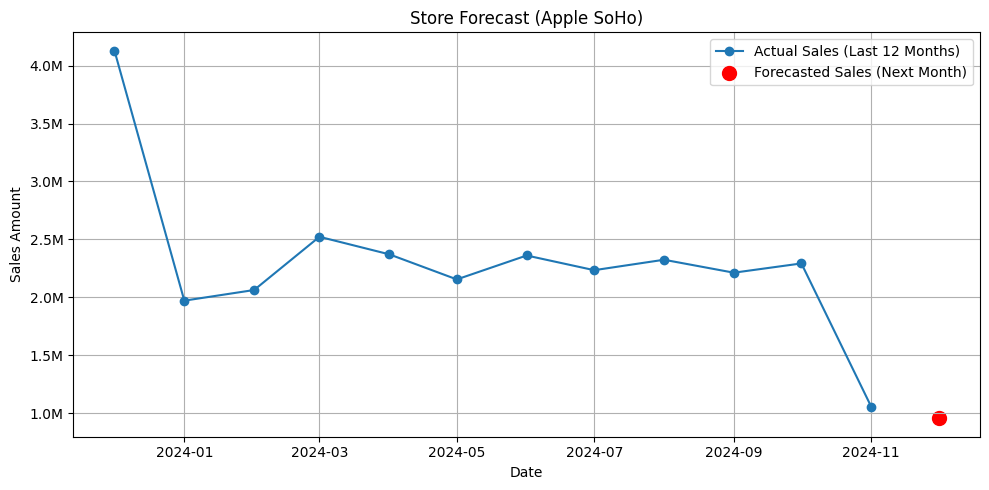

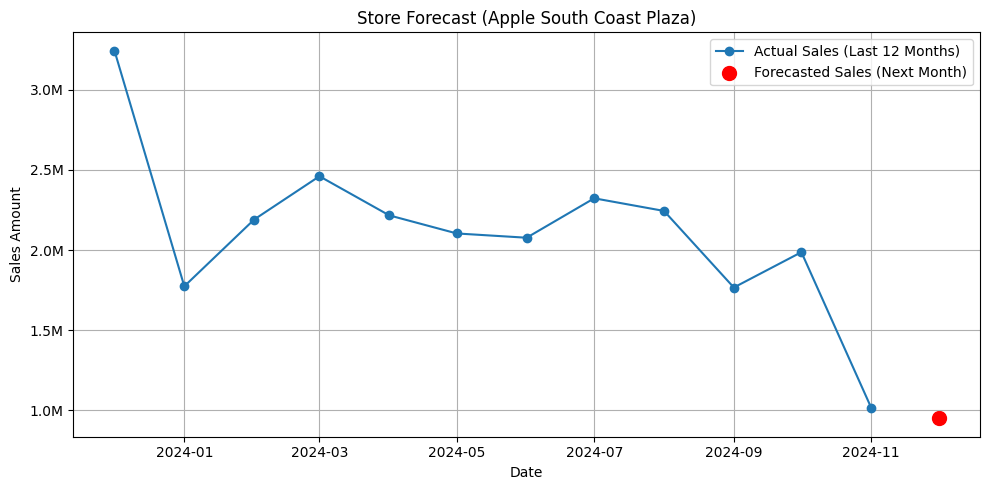

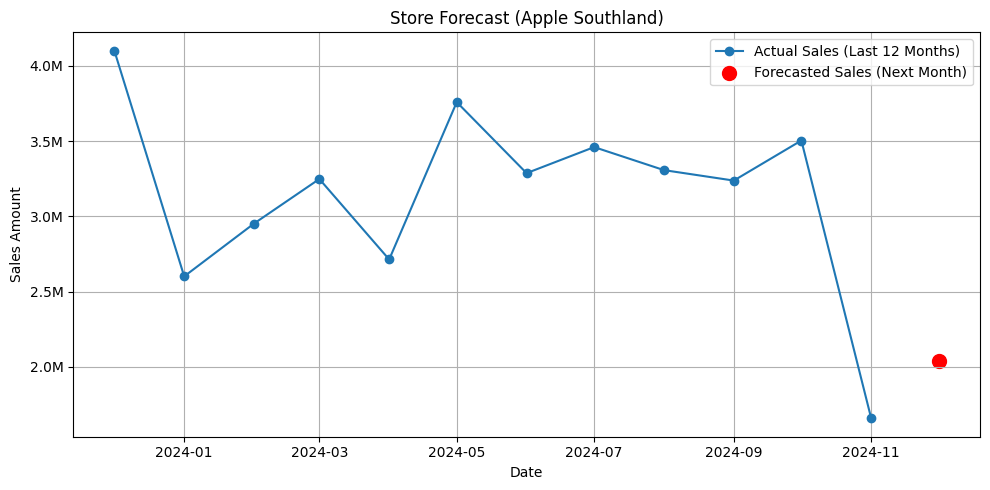

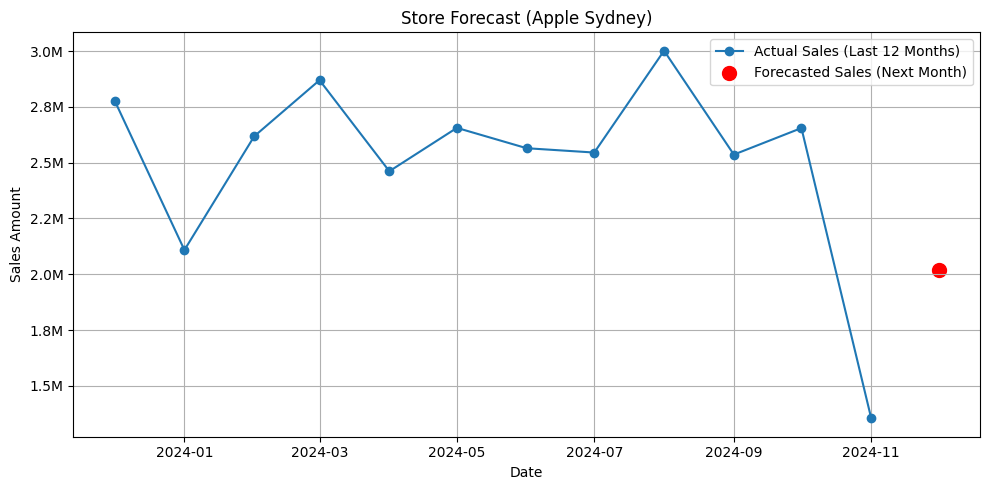

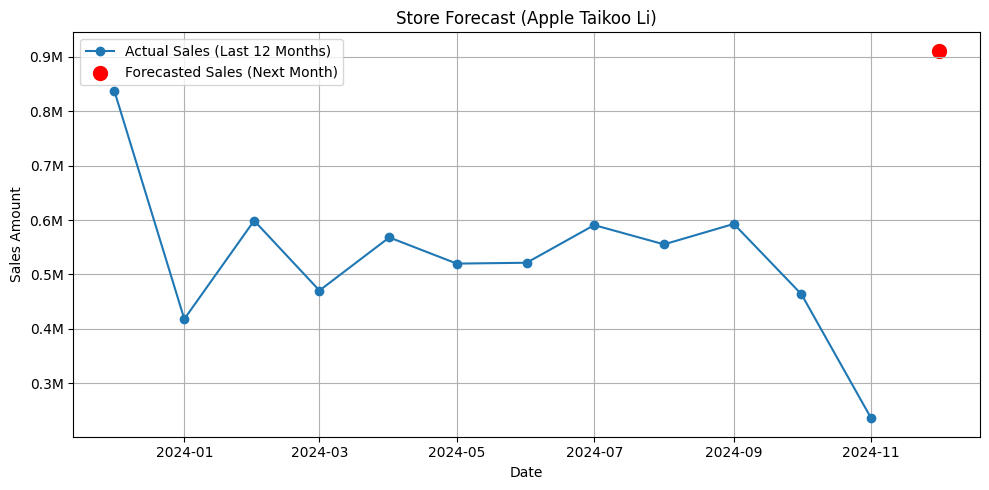

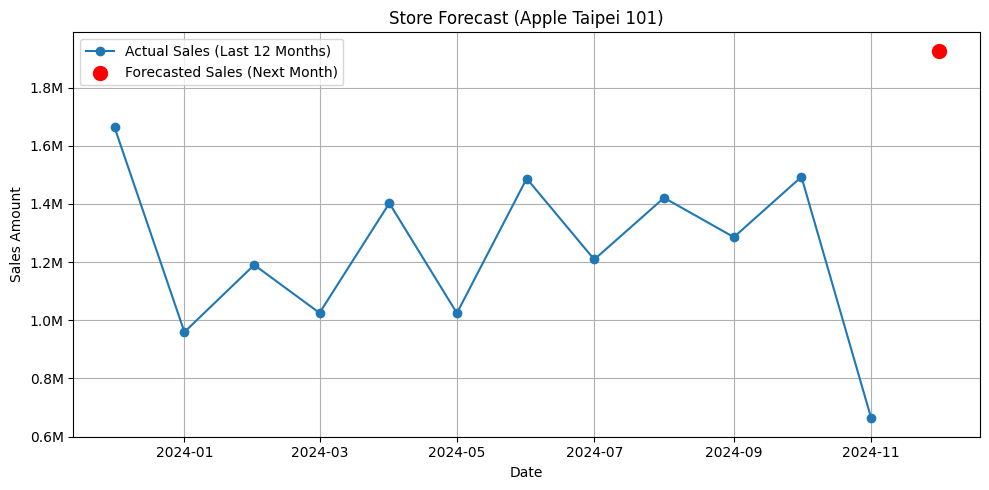

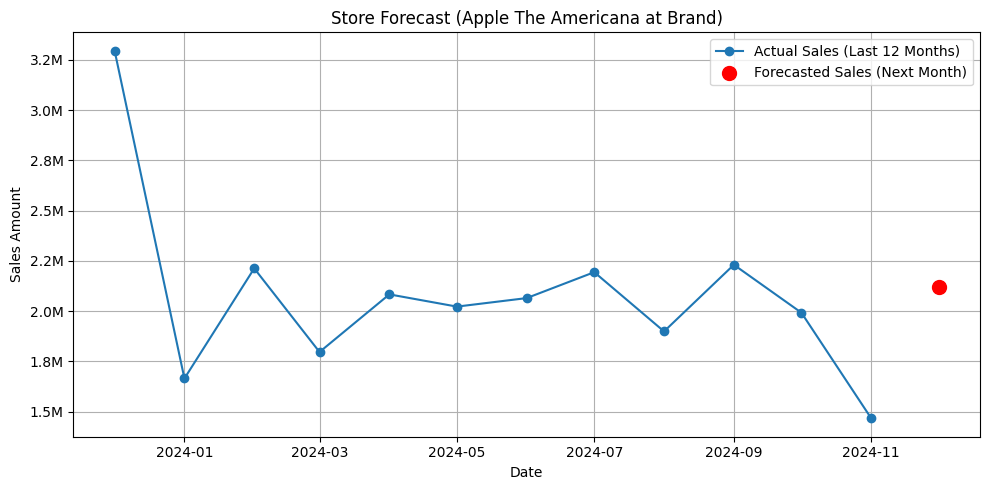

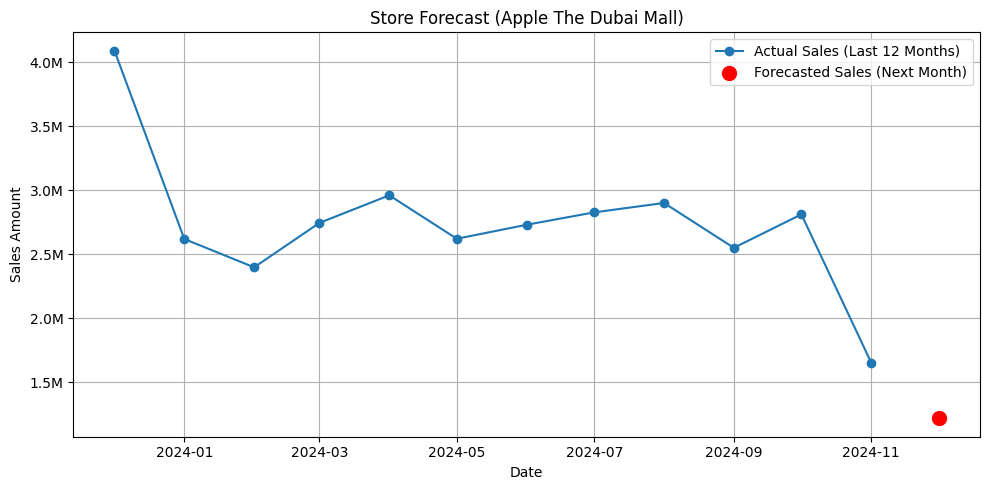

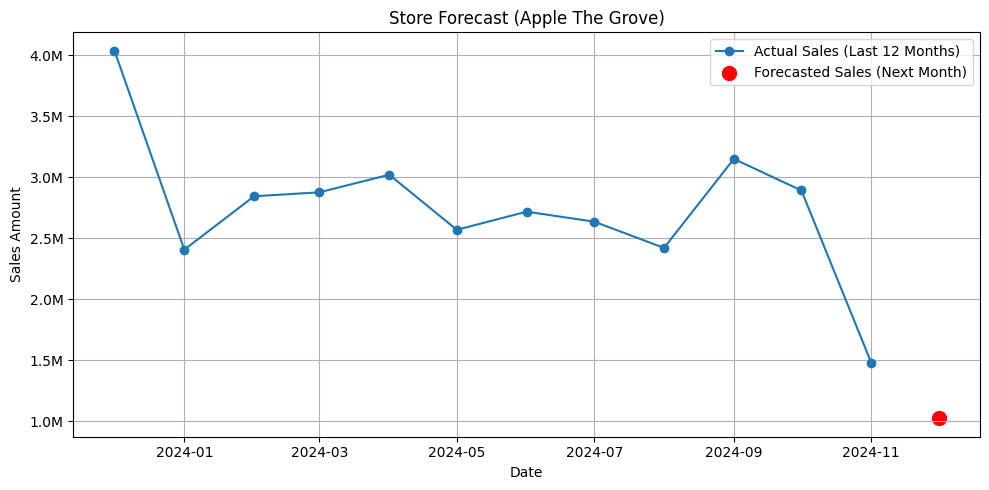

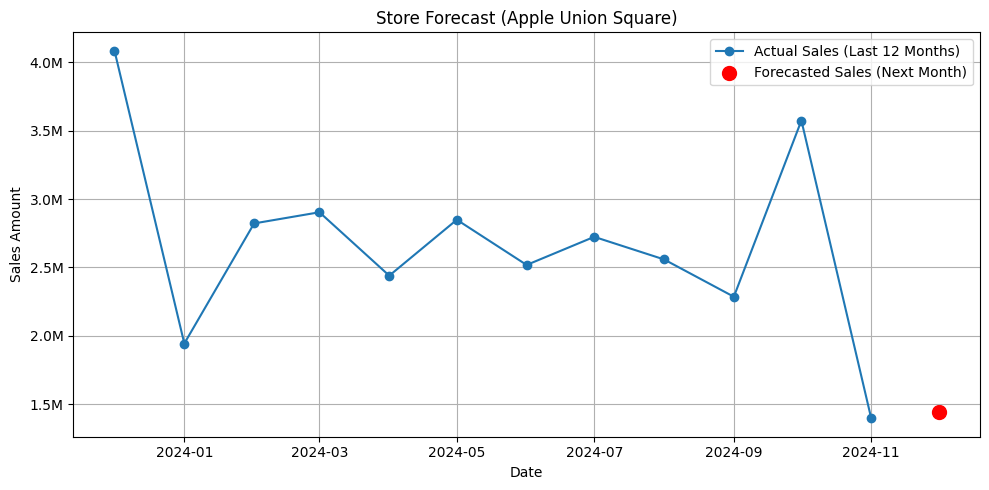

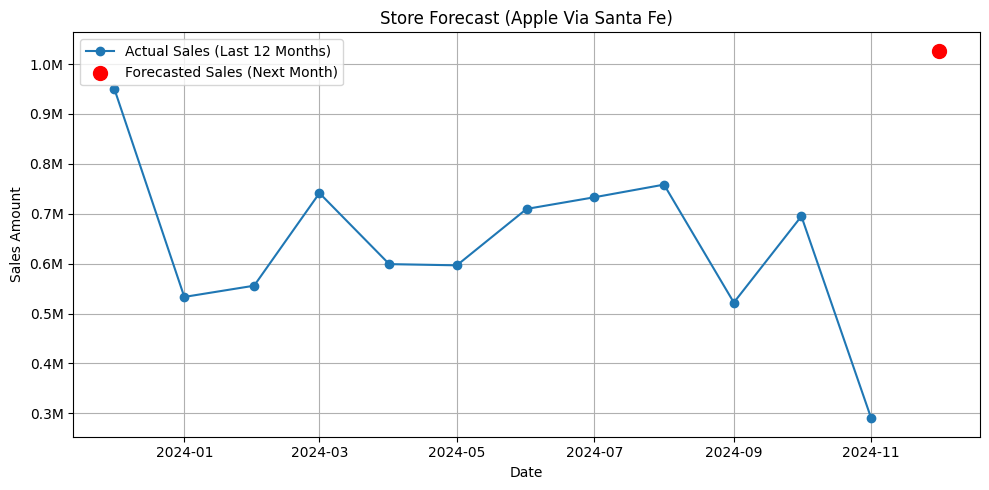

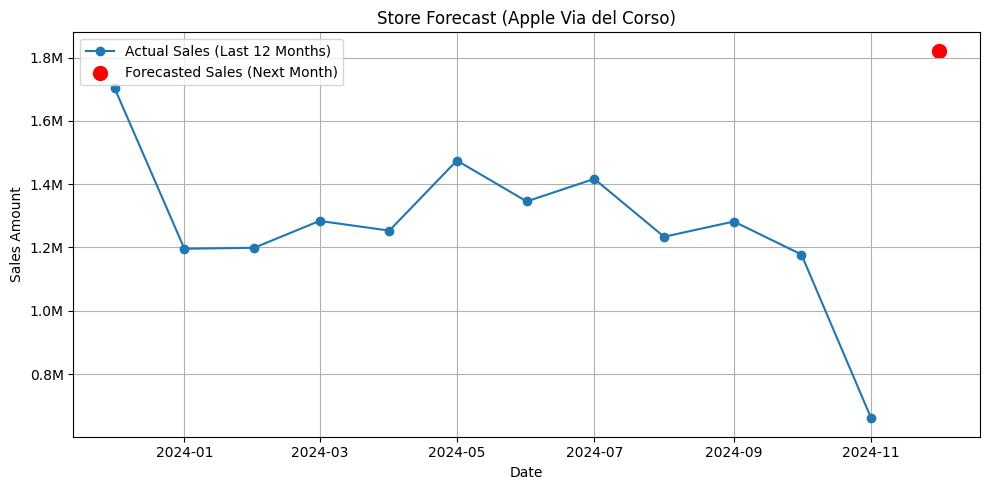

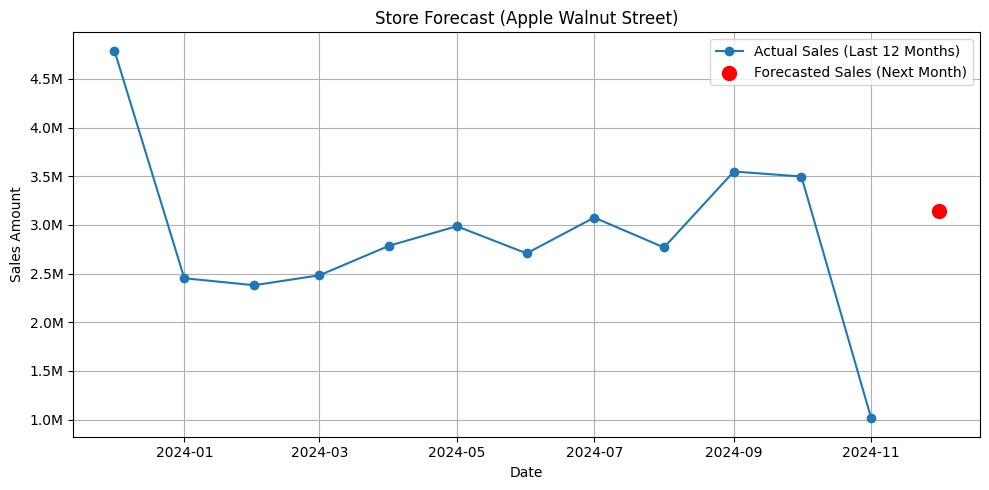

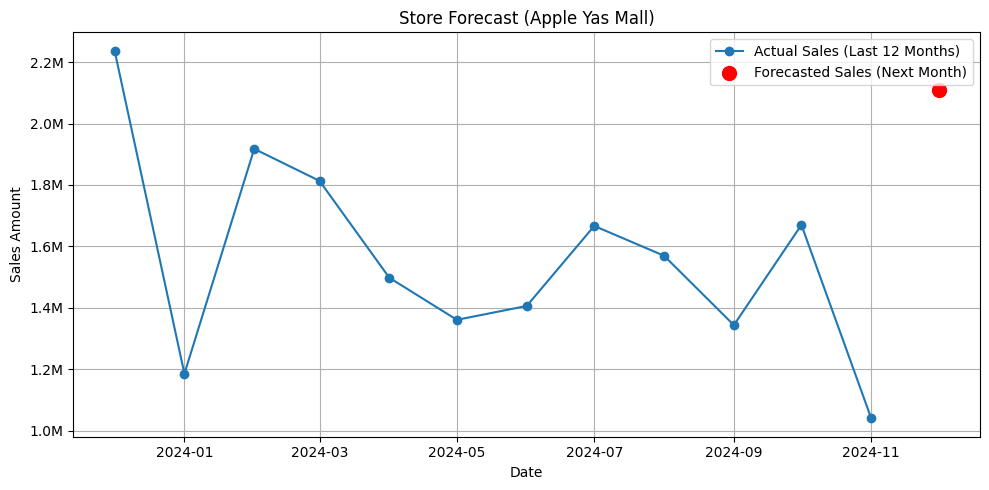

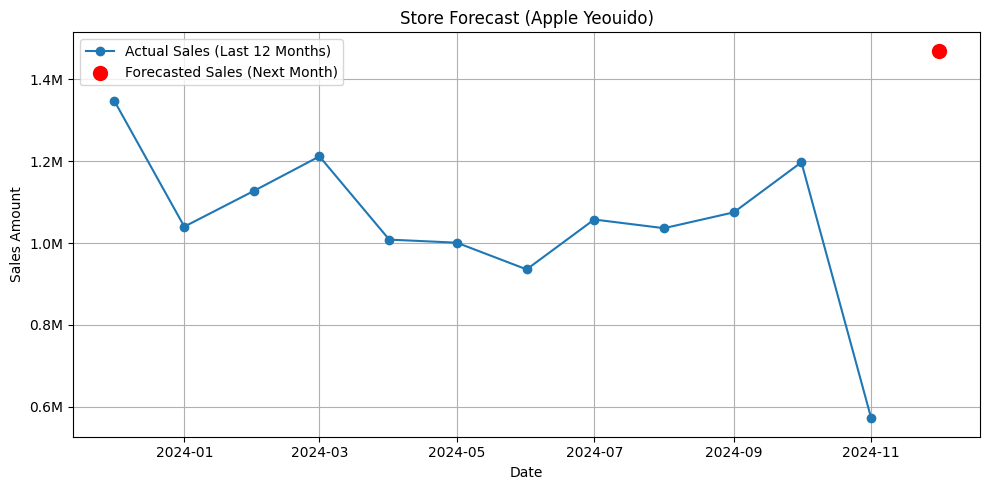

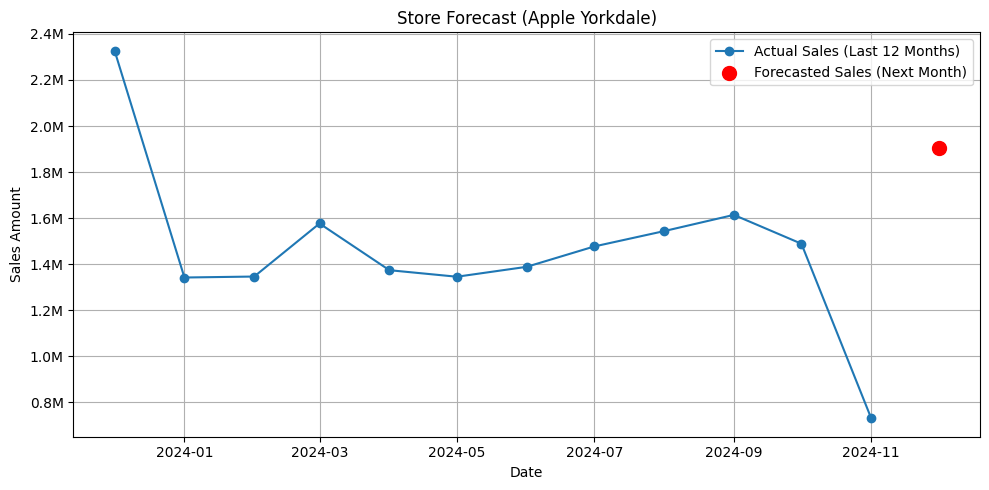

In [80]:
for store_id in forecast_df['store_id']:
    plot_store_forecast(store_id, monthly_df, forecast_df)

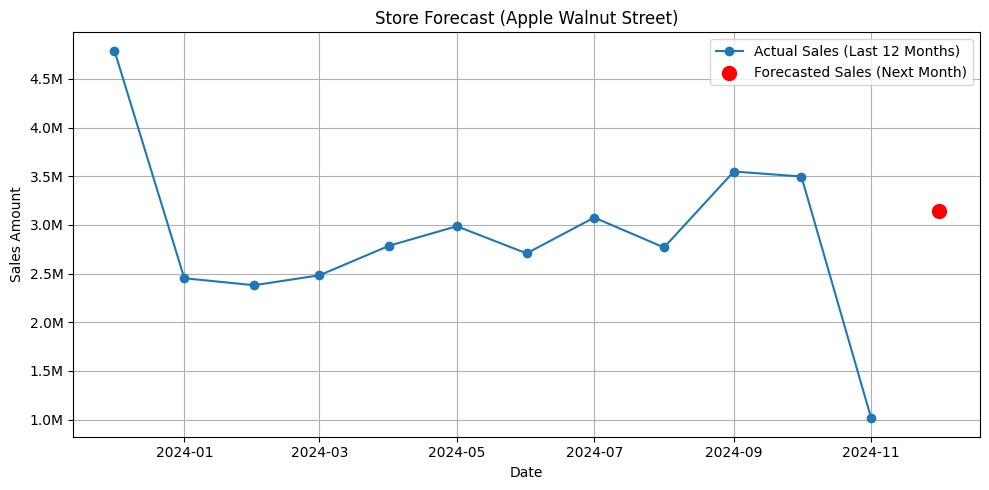

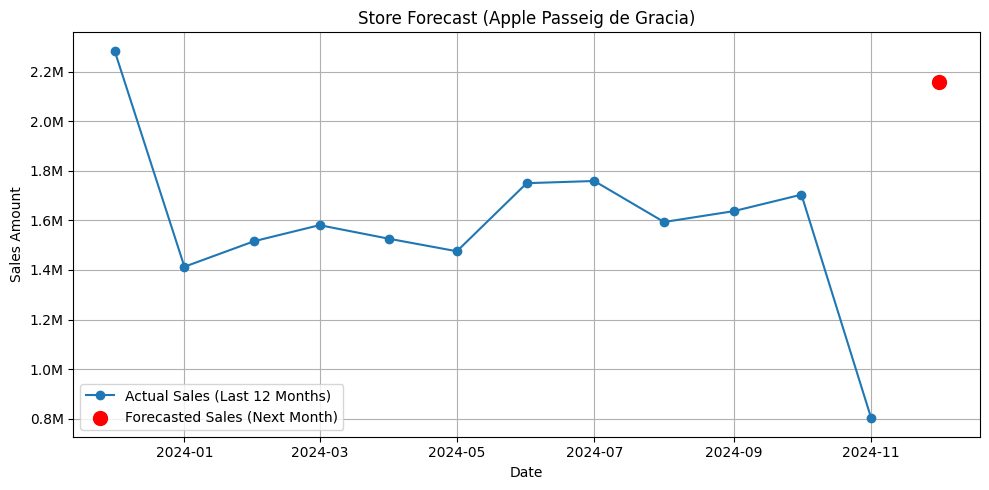

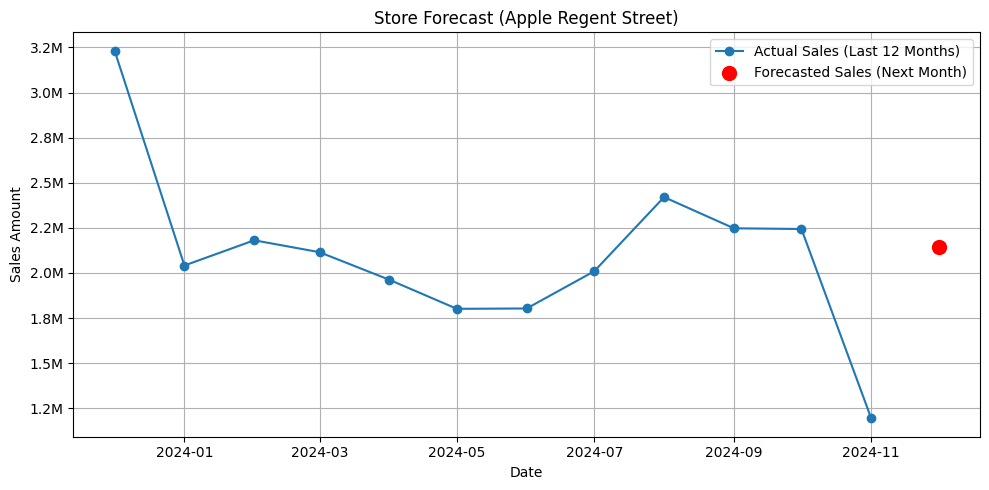

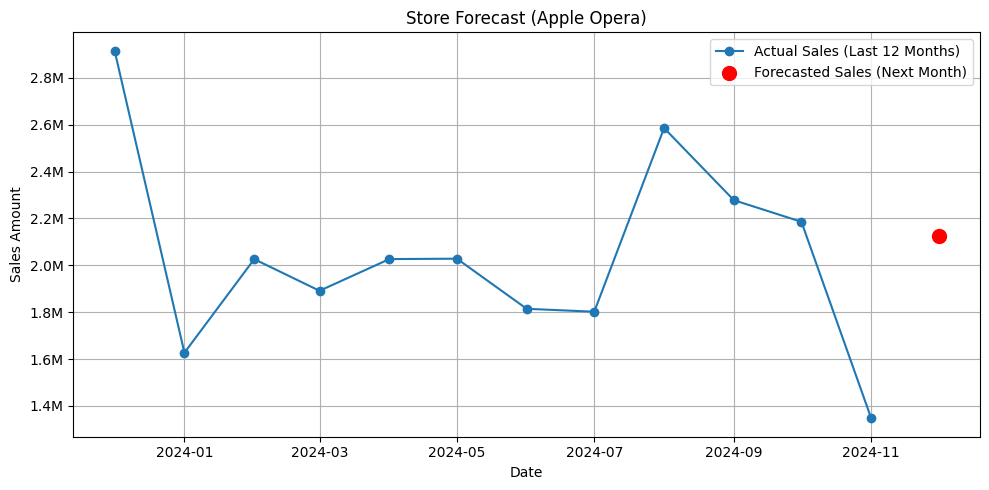

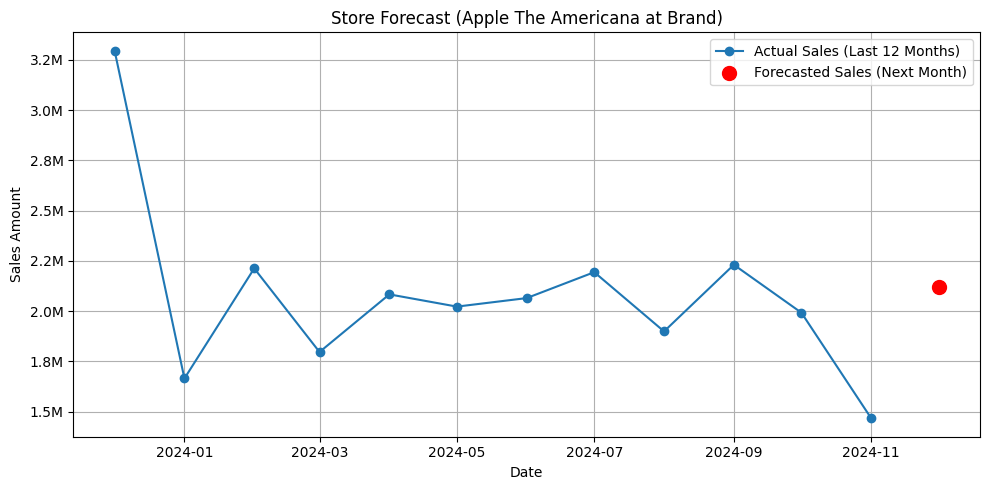

In [81]:
top_5_ids = (
    forecast_df
    .sort_values('forecasted_sales_next_month', ascending=False)
    .head(5)['store_id']
)

for store_id in top_5_ids:
    plot_store_forecast(store_id, monthly_df, forecast_df)

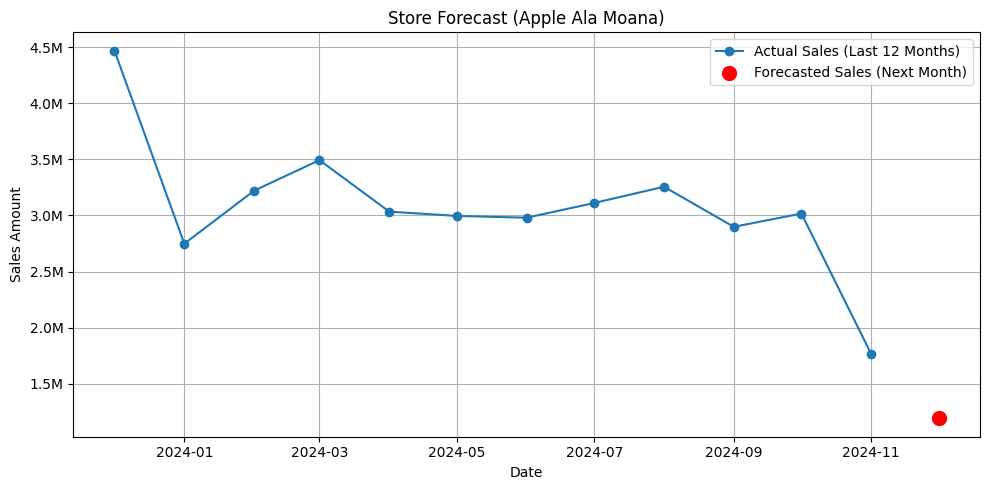

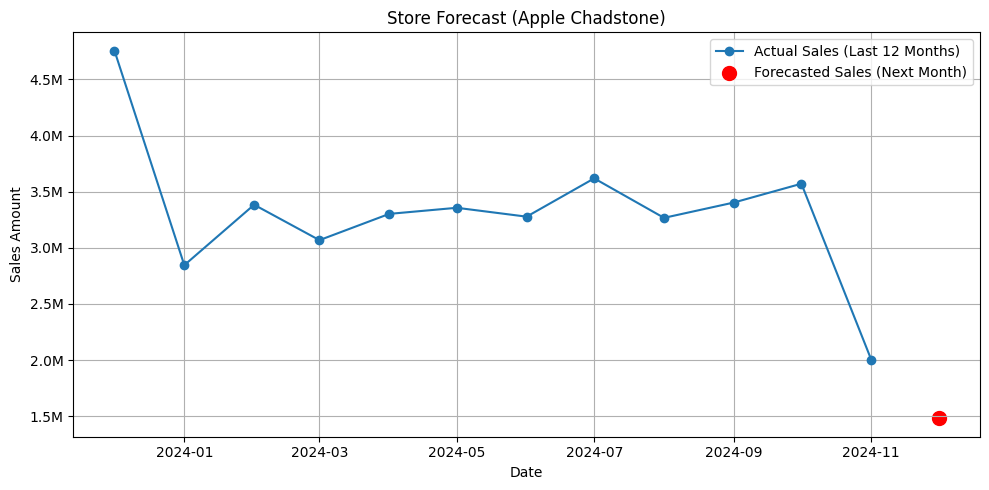

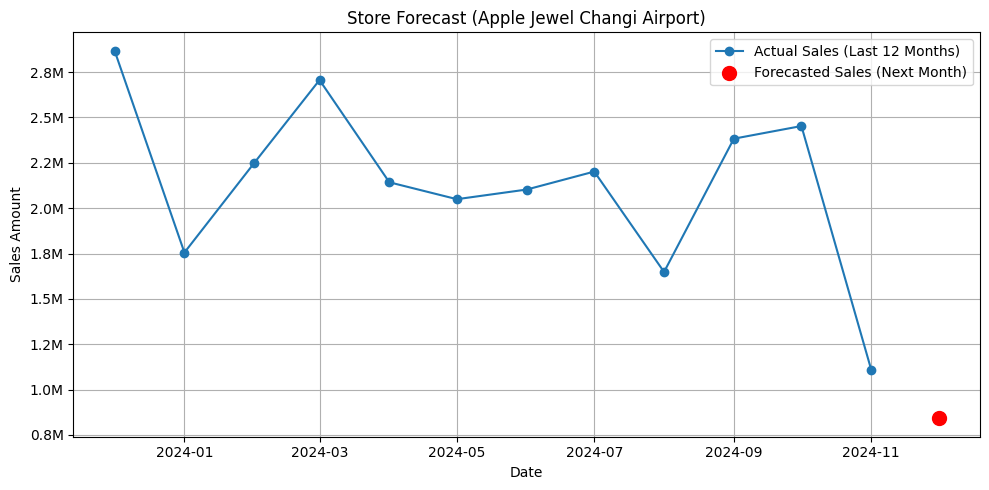

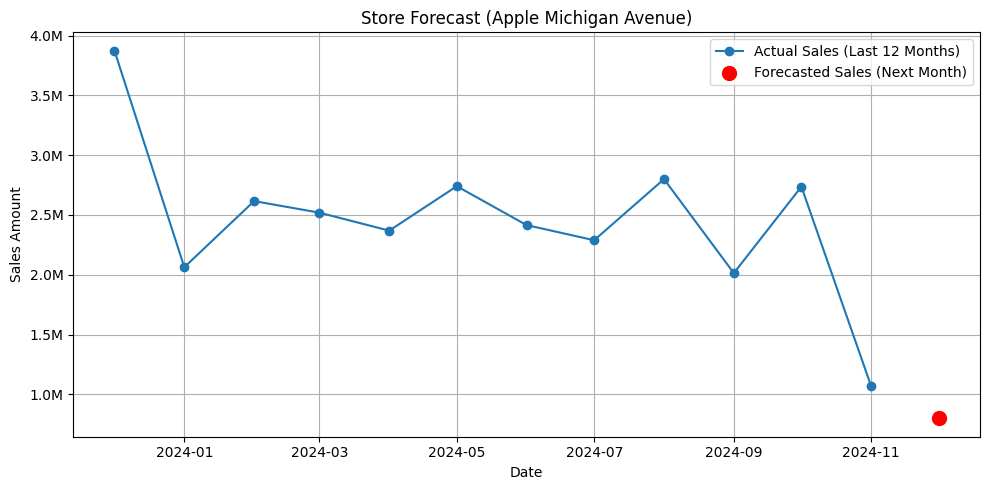

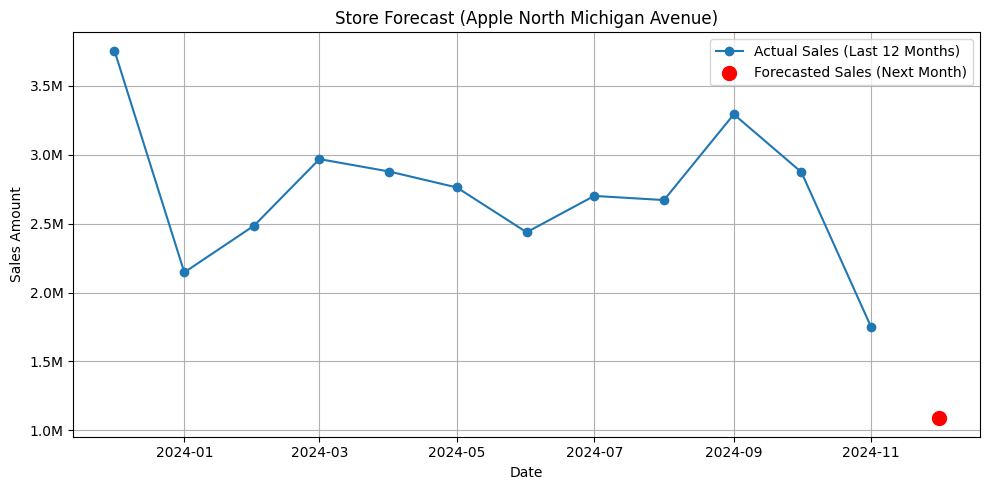

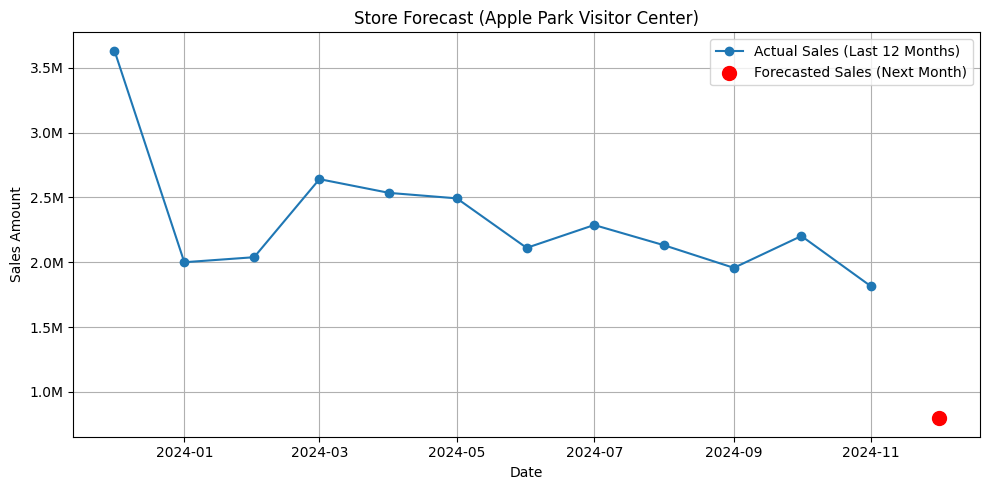

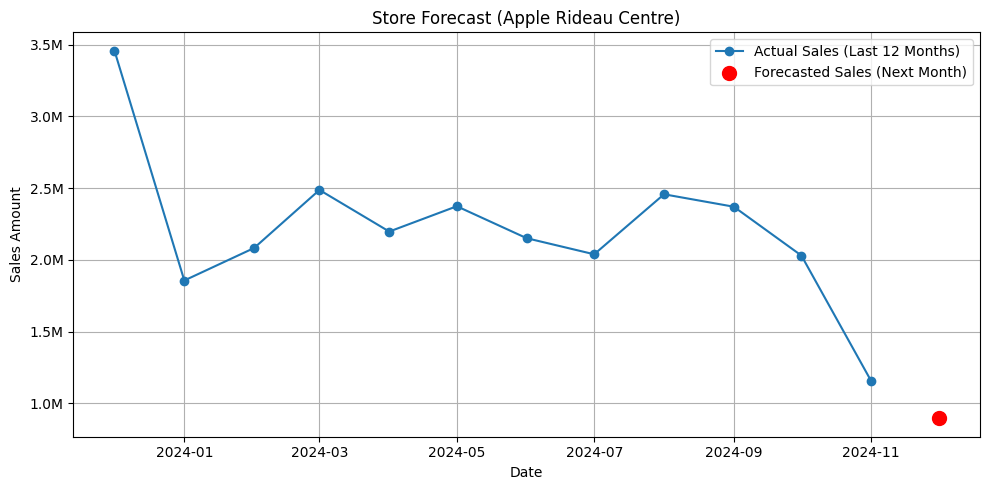

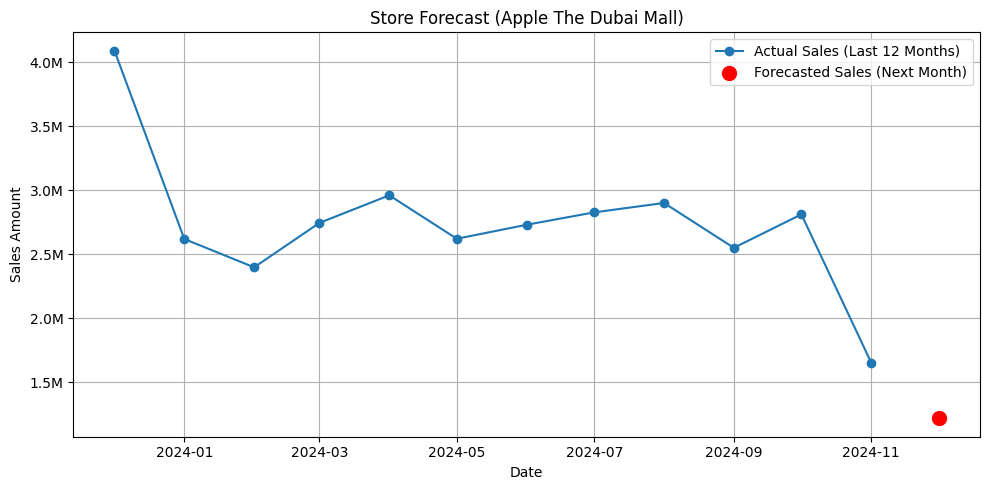

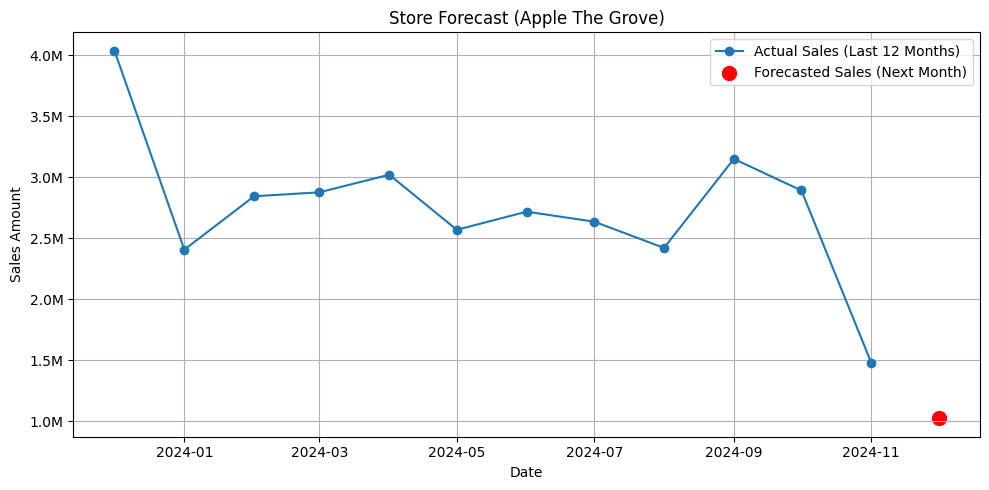

In [82]:
high_risk_ids = comparison_all_df[
    comparison_all_df['pct_change'] < -20
]['store_id']

for store_id in high_risk_ids:
    plot_store_forecast(store_id, monthly_df, forecast_df)

In [83]:
def plot_baseline_vs_lstm(store_id, comparison_df):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    store_row = comparison_df[comparison_df['store_id'] == store_id].iloc[0]

    store_name = store_row['store_name']
    naive_val  = store_row['naive_forecast']
    lstm_val   = store_row['forecasted_sales_next_month']

    plt.figure(figsize=(5,4))

    plt.bar(
        ['Naive Baseline', 'LSTM Forecast'],
        [naive_val, lstm_val],
        color=['gray', 'steelblue']
    )

    plt.title(f"Baseline vs LSTM\n{store_name}")
    plt.ylabel("Sales Amount")

    # تنسيق بالمليون
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
    )

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

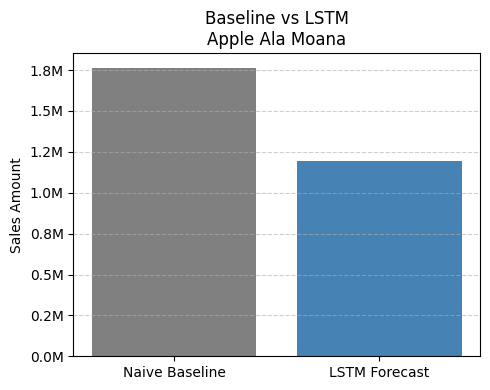

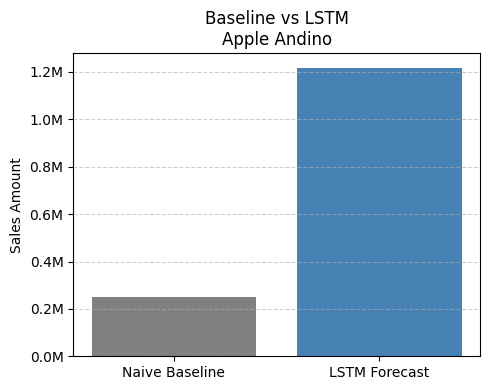

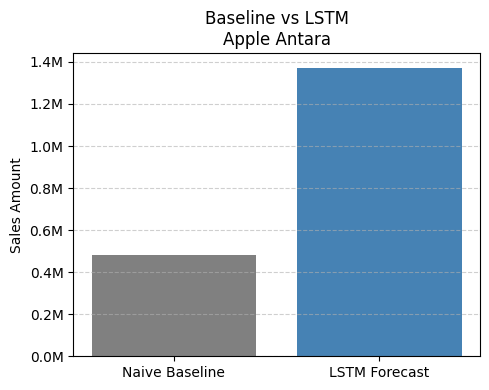

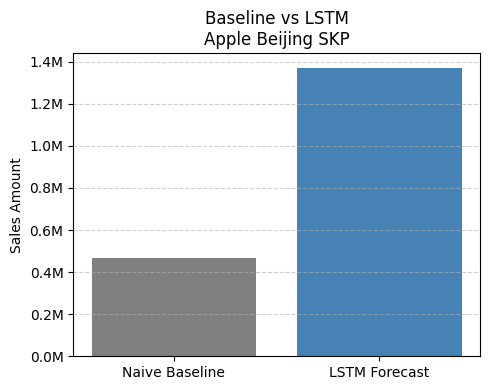

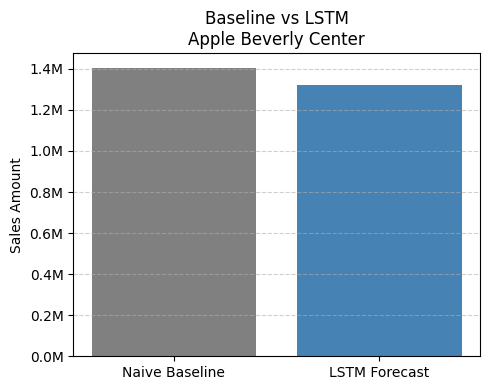

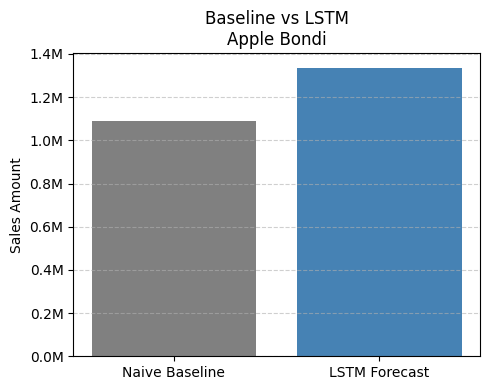

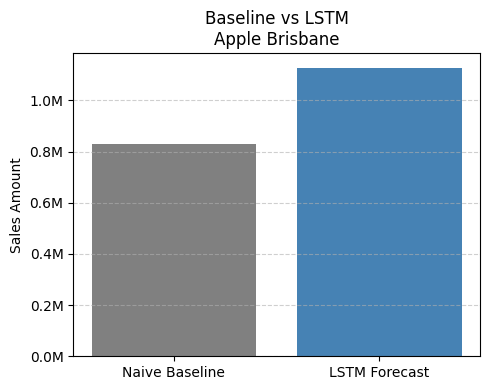

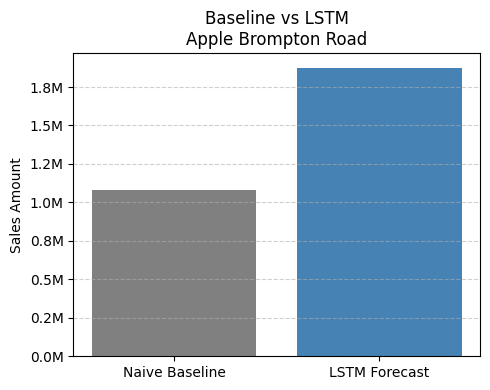

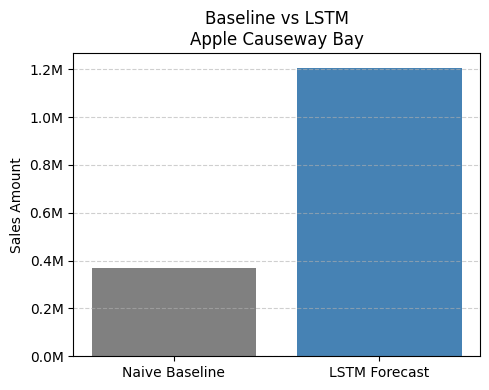

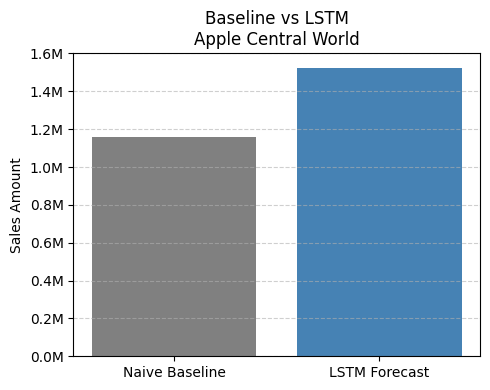

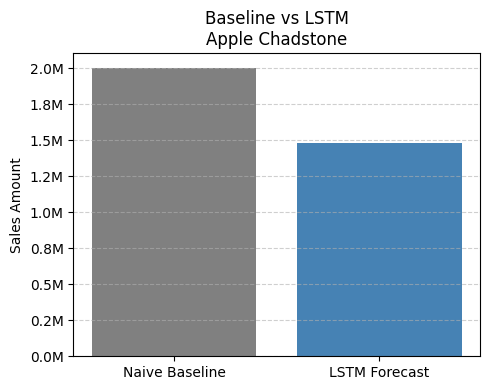

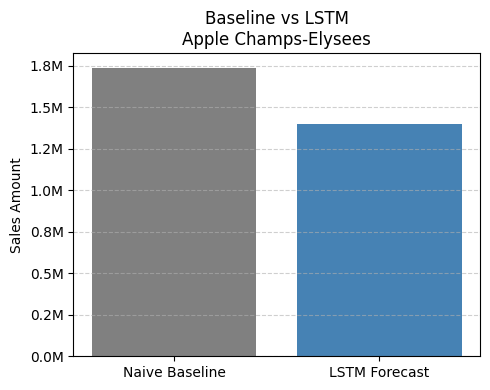

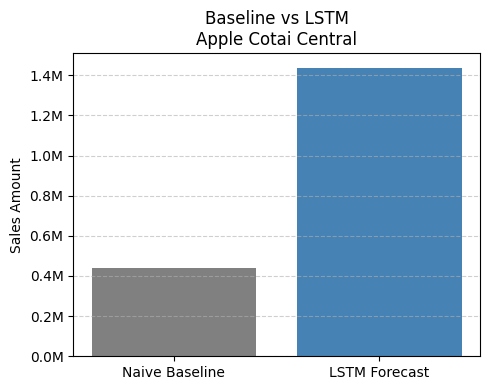

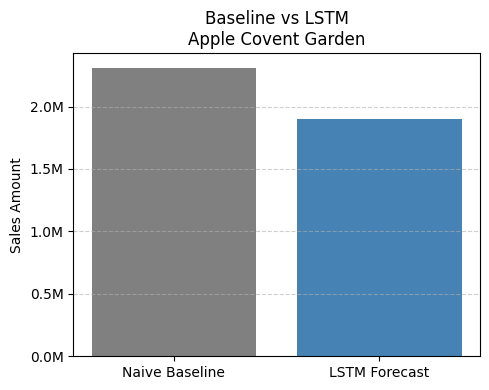

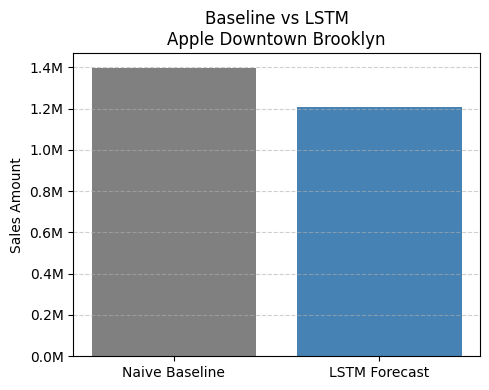

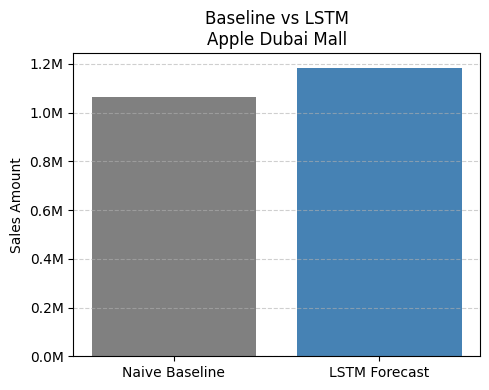

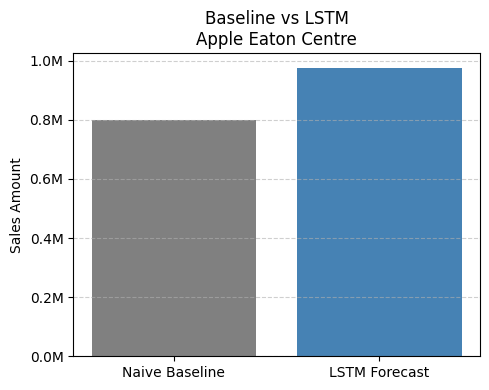

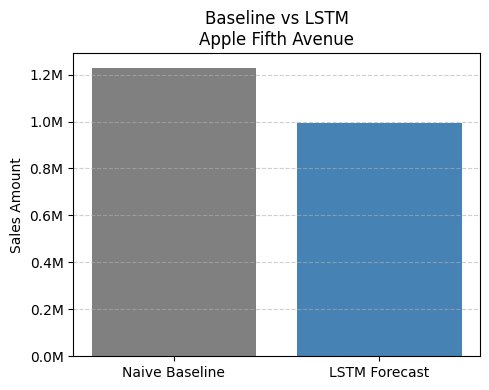

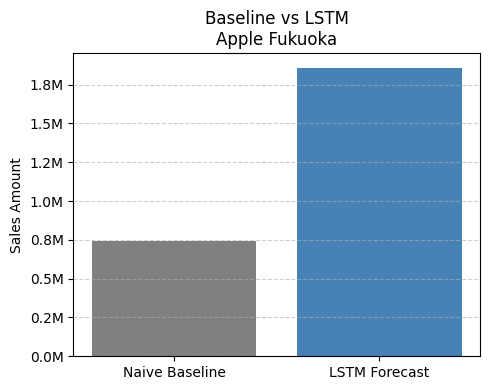

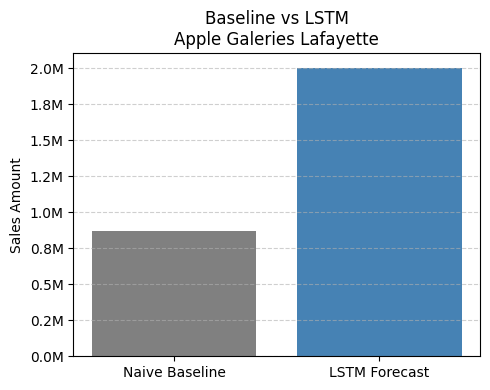

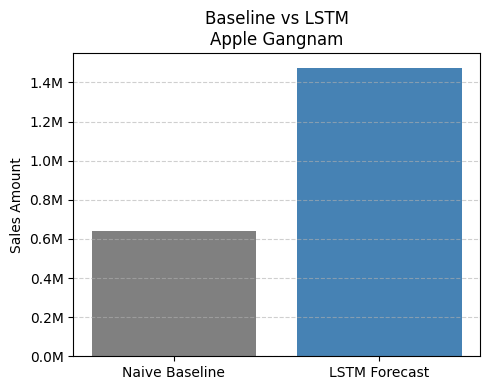

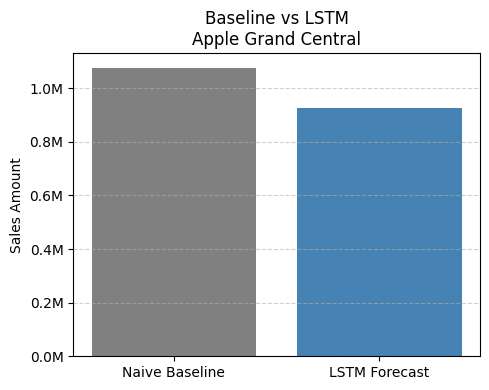

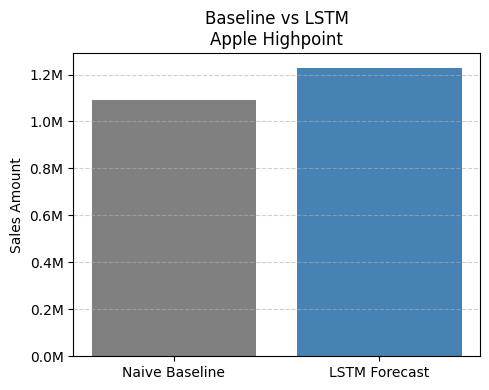

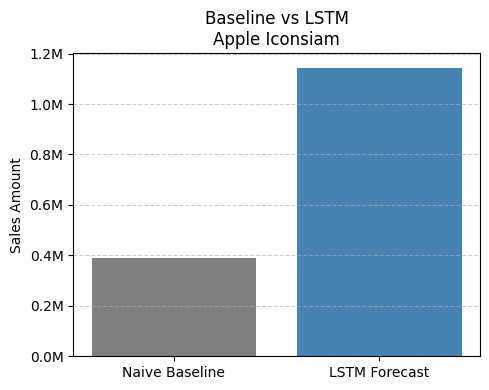

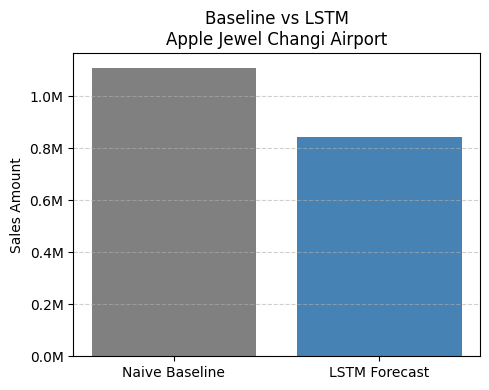

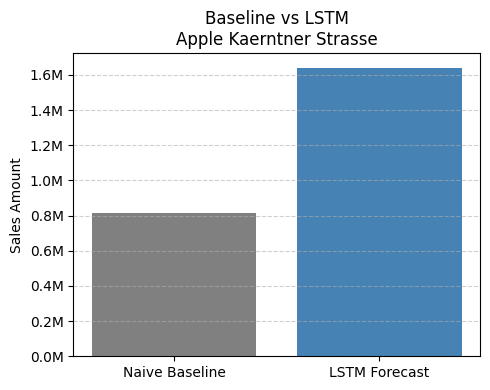

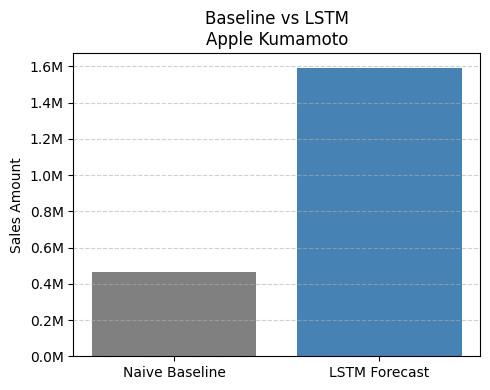

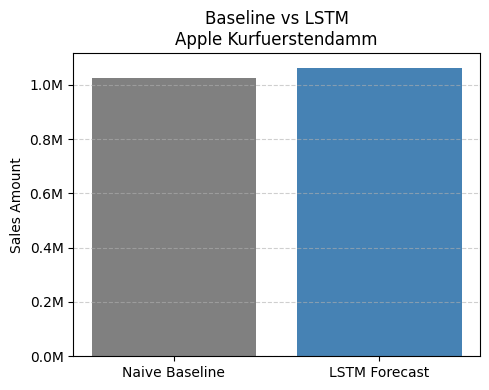

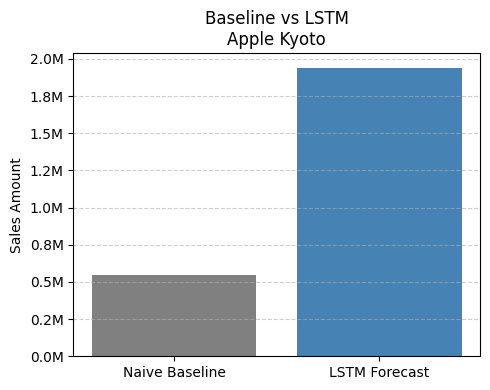

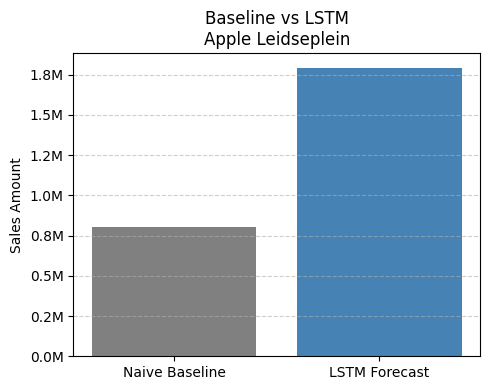

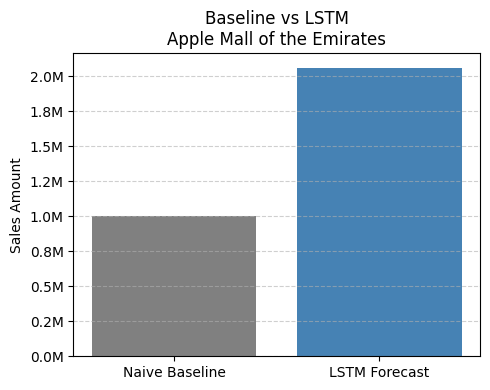

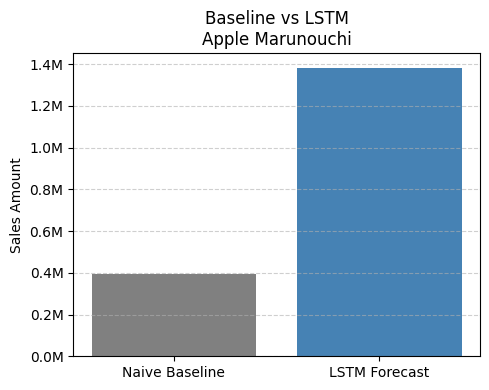

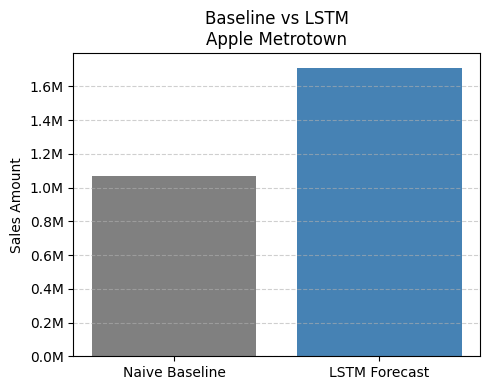

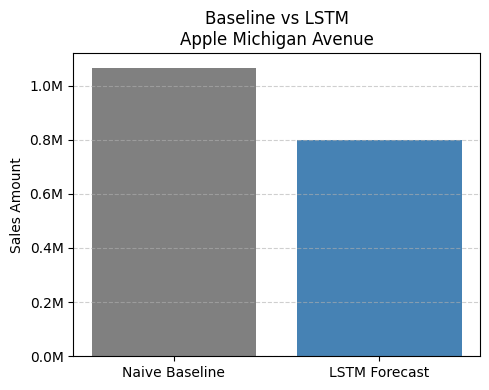

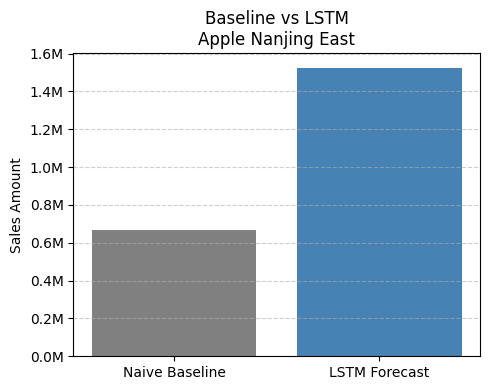

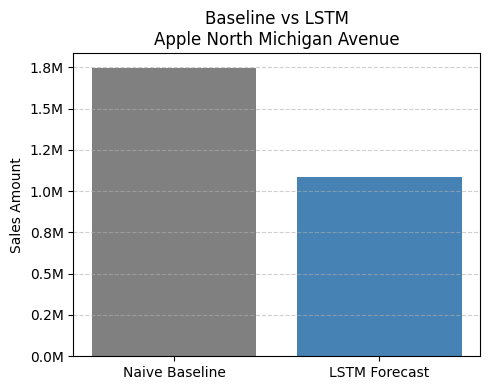

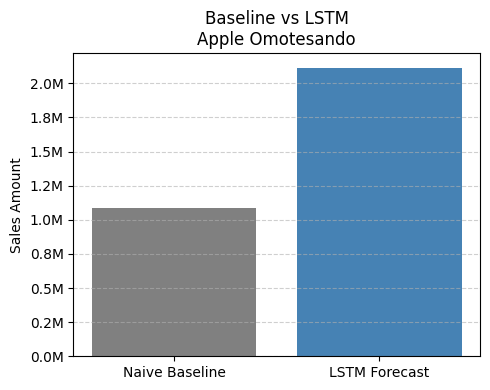

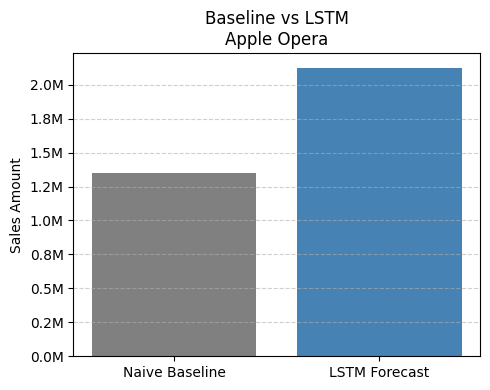

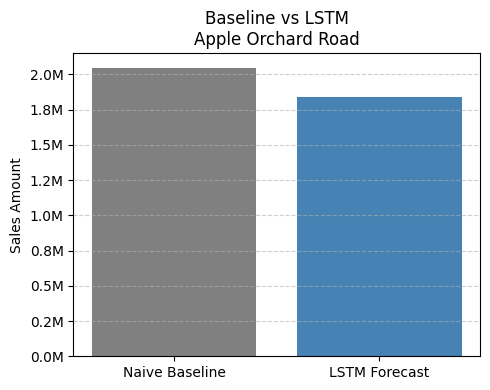

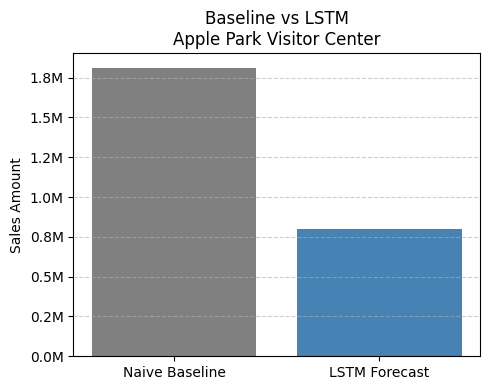

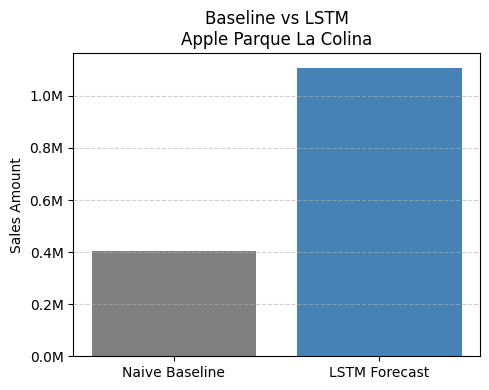

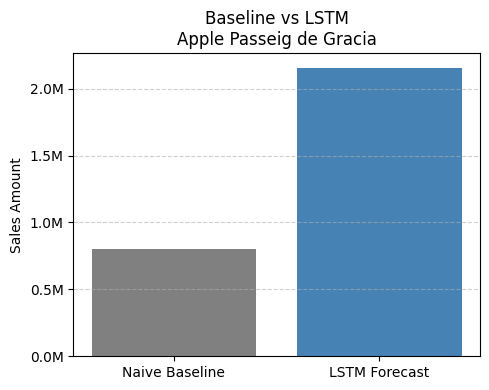

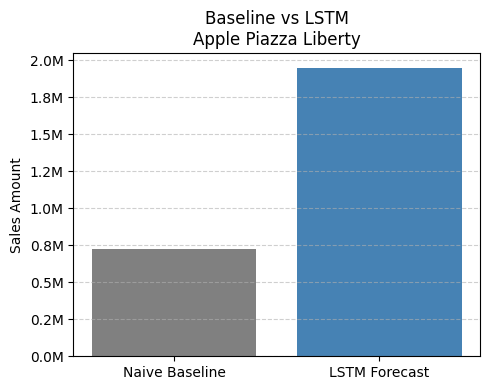

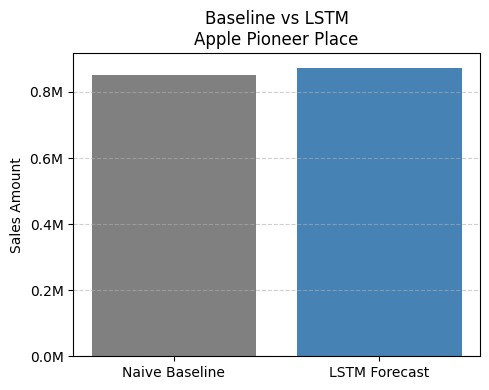

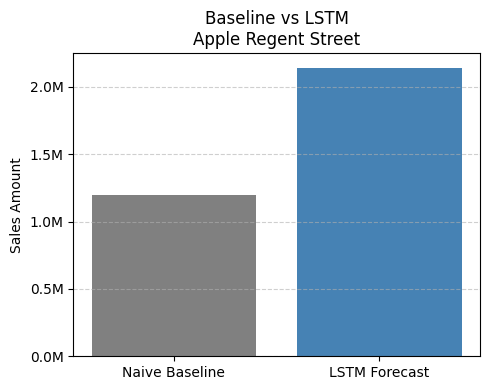

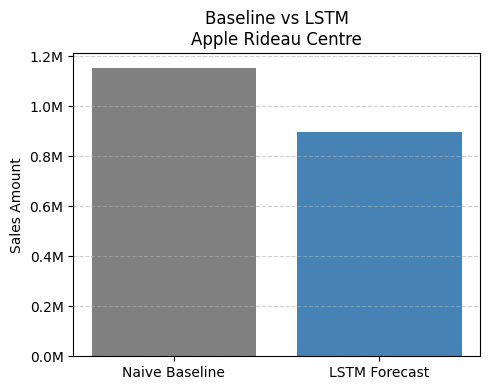

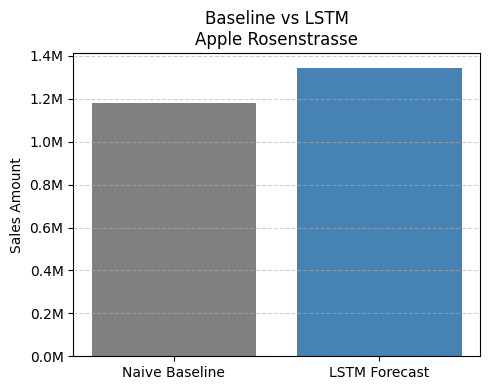

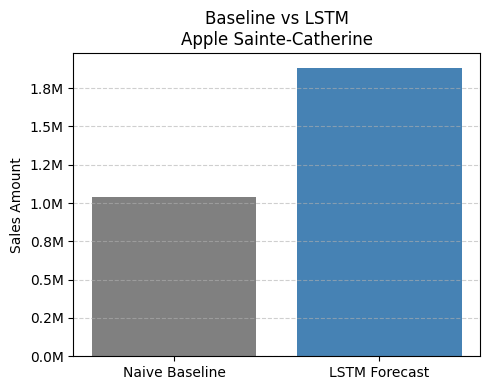

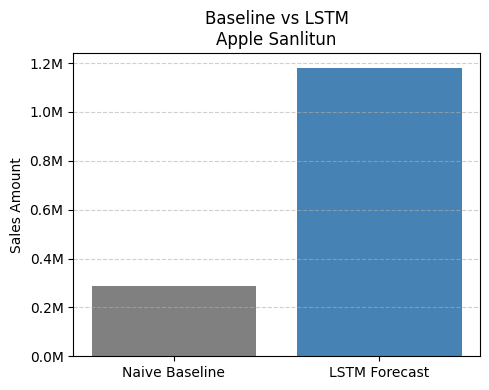

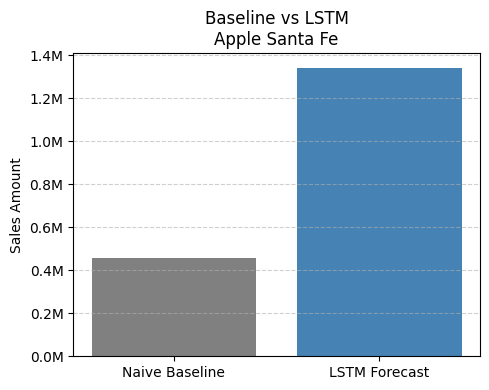

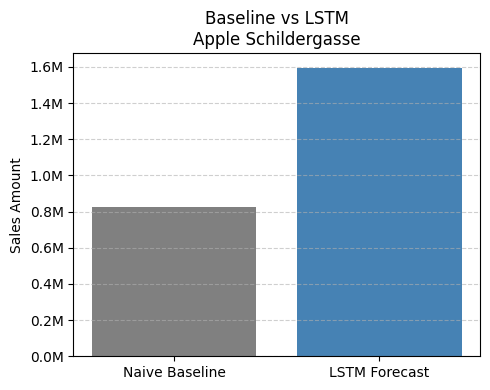

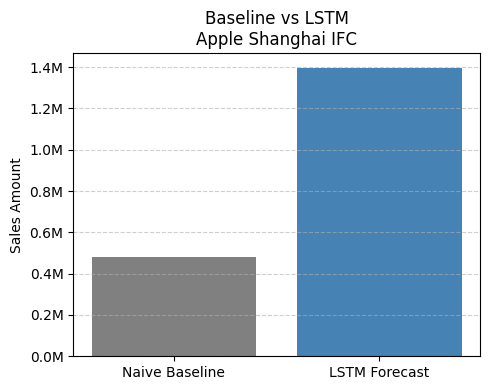

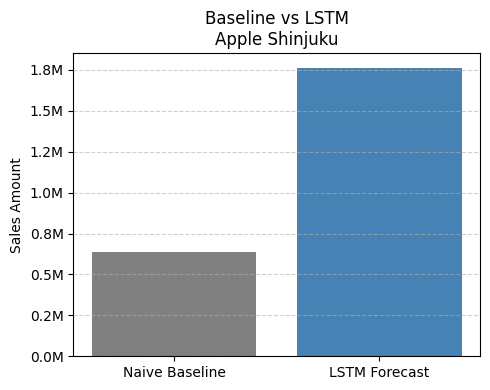

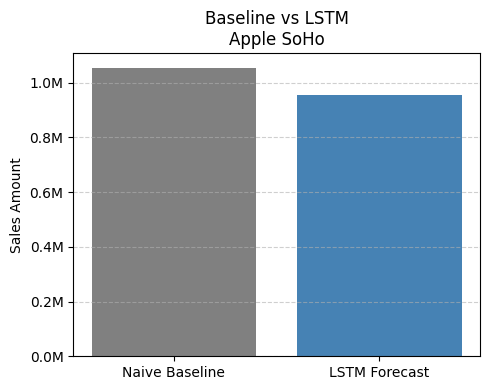

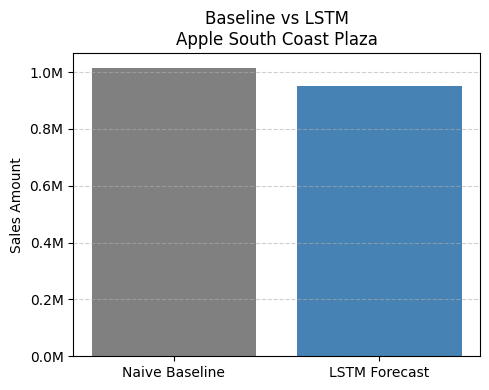

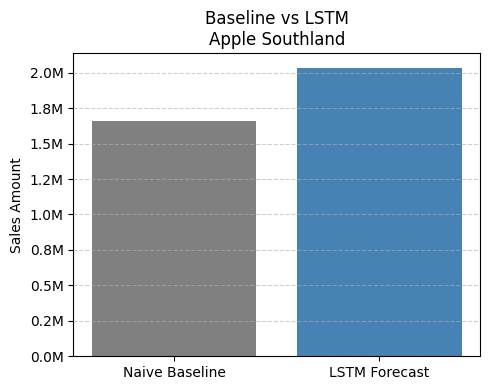

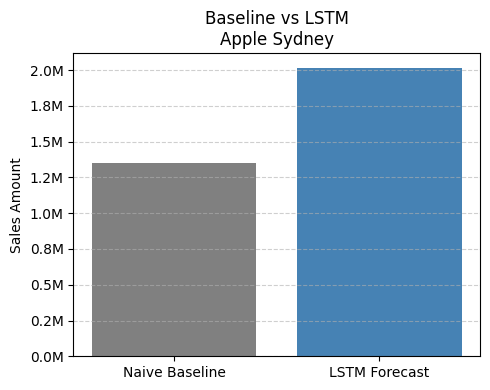

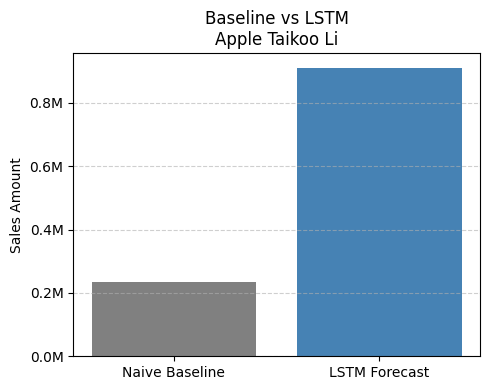

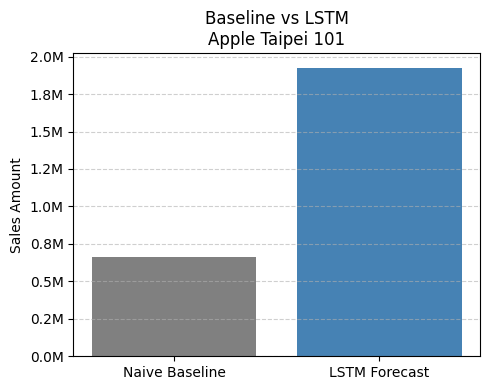

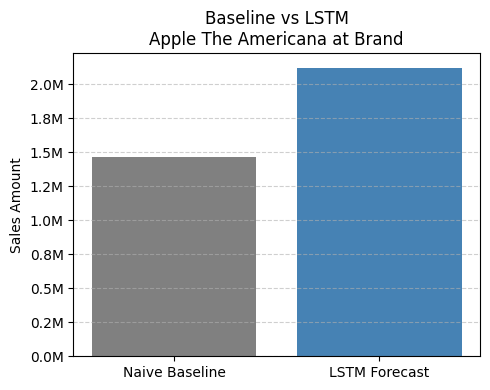

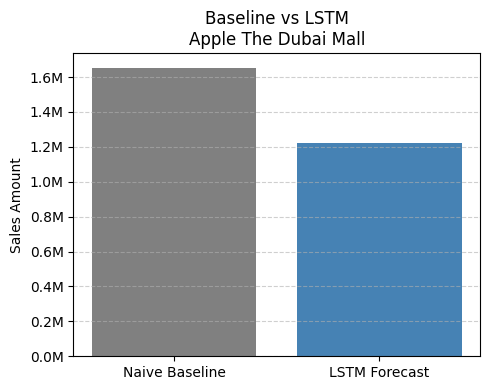

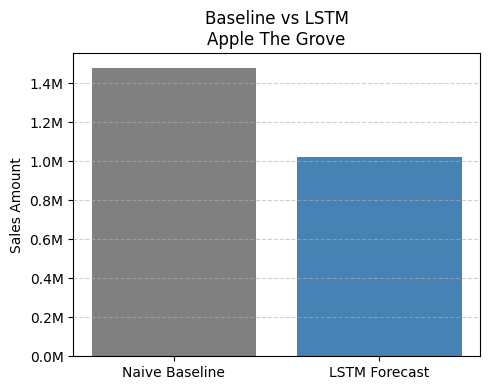

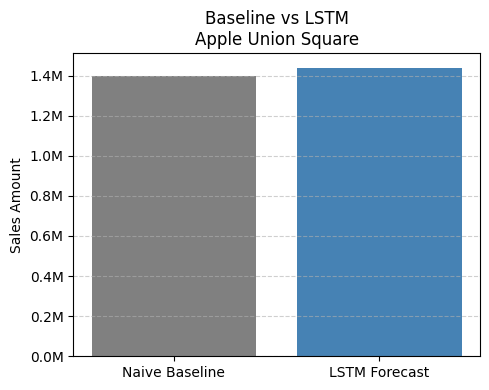

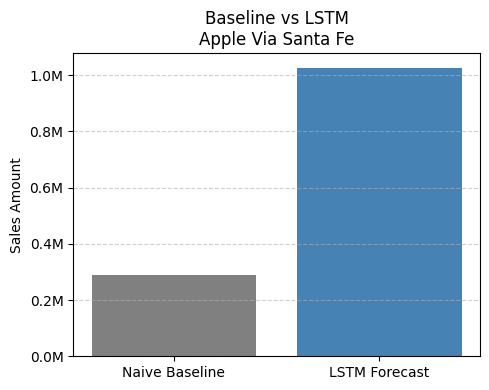

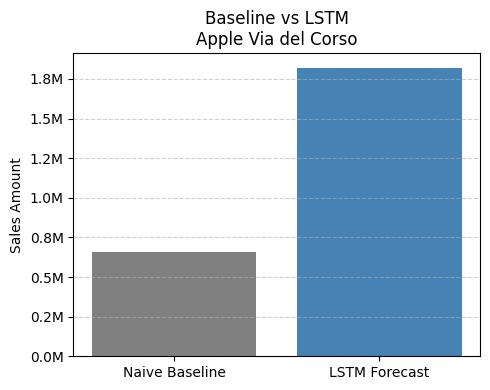

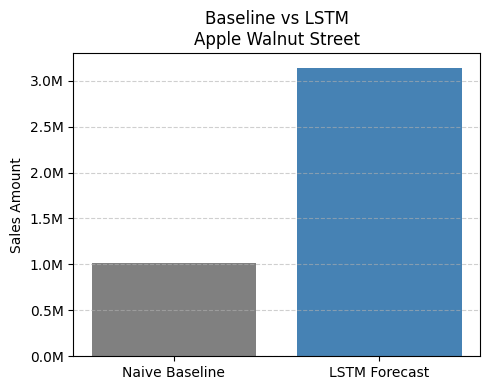

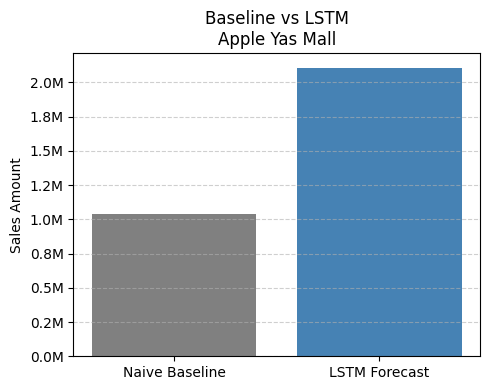

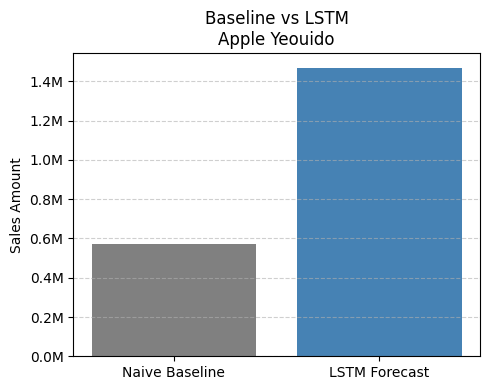

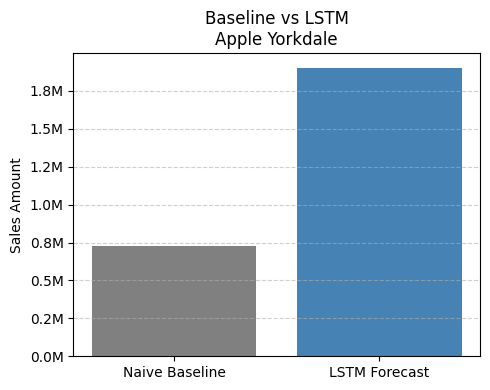

In [84]:
for store_id in comparison_all_df['store_id']:
    plot_baseline_vs_lstm(store_id, comparison_all_df)

🎯 الهدف

لكل Store نعرض:

Naive Baseline (آخر شهر فعلي)

LSTM Forecast (الشهر القادم)

في Graph واحد واضح.

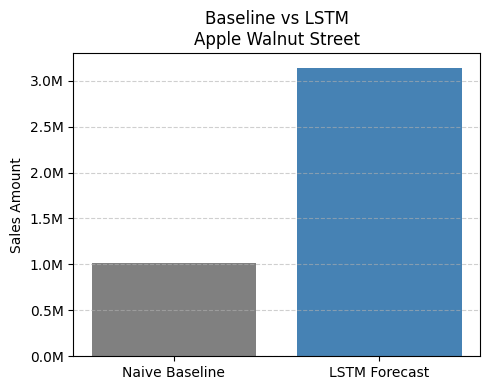

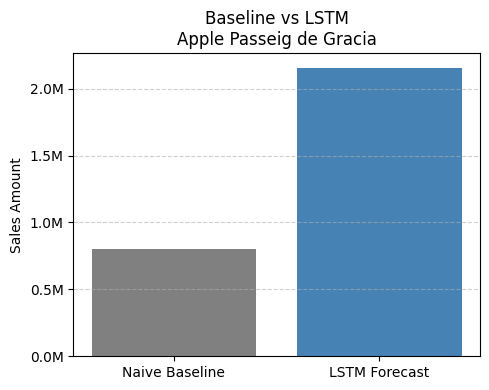

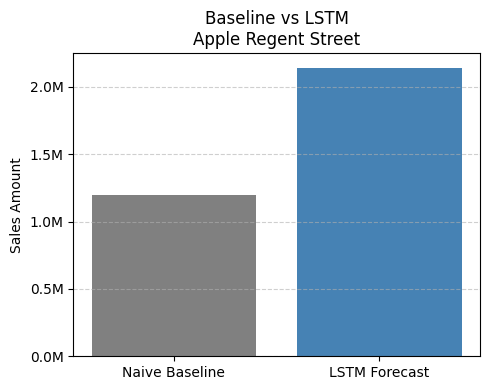

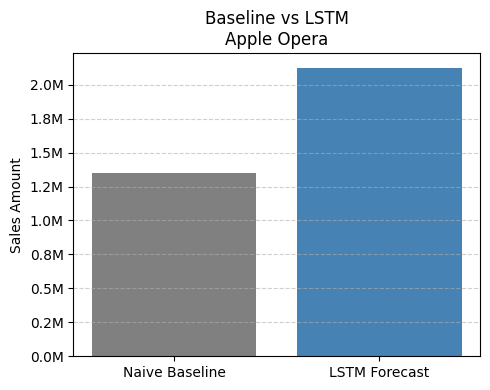

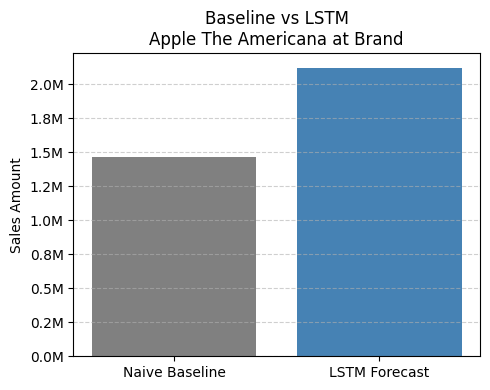

In [85]:
top_5_ids = (
    comparison_all_df
    .sort_values('forecasted_sales_next_month', ascending=False)
    .head(5)['store_id']
)

for store_id in top_5_ids:
    plot_baseline_vs_lstm(store_id, comparison_all_df)

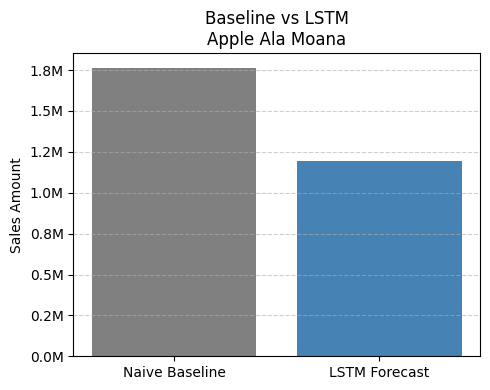

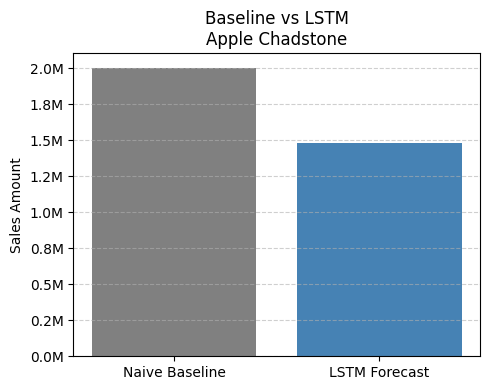

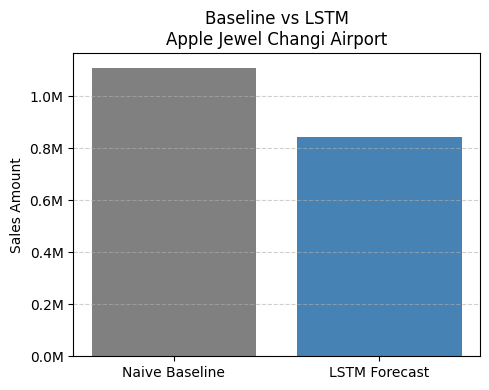

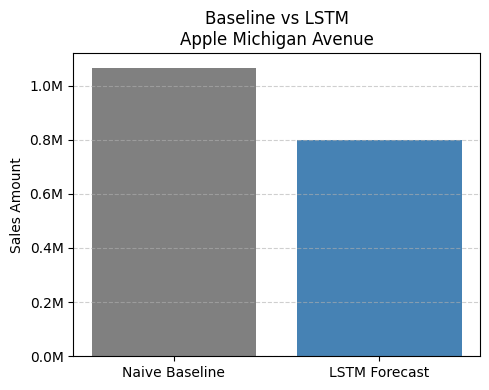

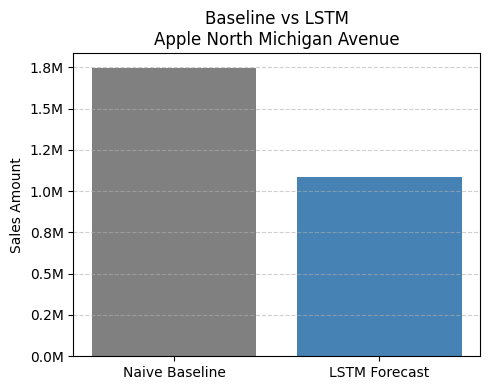

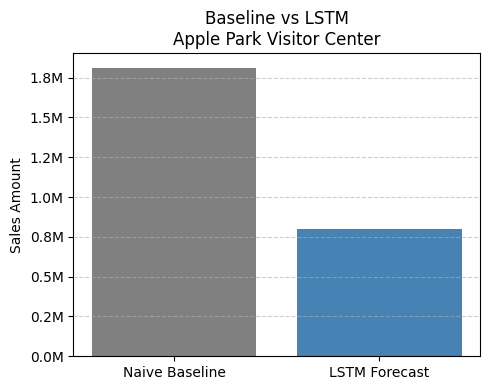

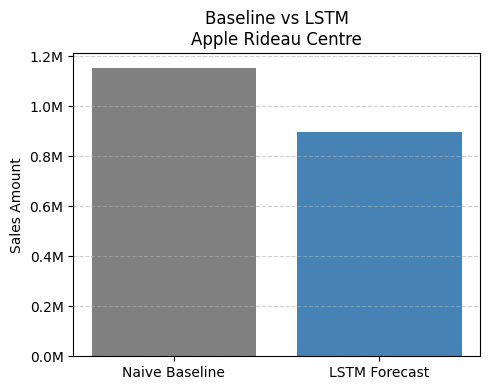

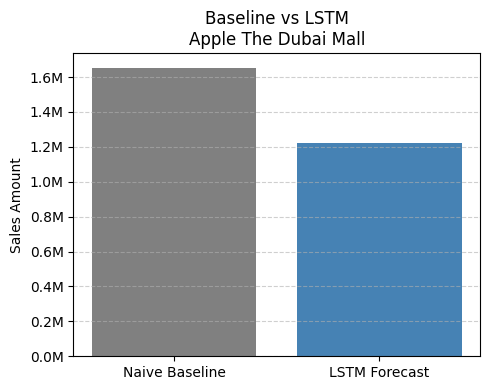

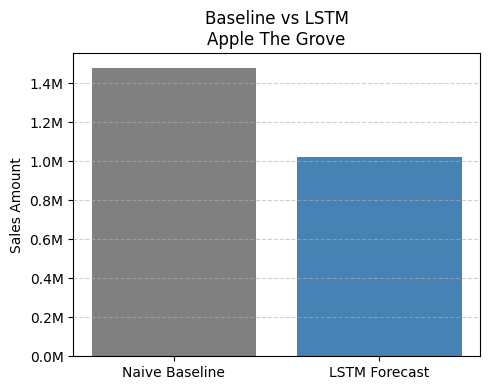

In [86]:
high_risk_ids = comparison_all_df[
    comparison_all_df['pct_change'] < -20
]['store_id']

for store_id in high_risk_ids:
    plot_baseline_vs_lstm(store_id, comparison_all_df)

🧠 إزاي تفسّر Graph واحد؟

لو LSTM < Naive:

الموديل شايف هبوط

لو LSTM ≈ Naive:

استقرار

لو LSTM > Naive:

نمو متوقّع
“Baseline and LSTM forecasts were compared at the store level to assess whether predictions relied solely on recent observations or incorporated broader temporal patterns.”